# Project Name — Vaccination Data Analysis and Visualization

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**            - Ankit Dash

# **Project Summary**

This project analyses global vaccination data published by the World Health Organization to evaluate how immunization programmes have performed across countries, regions and diseases between 1980 and 2023.

Five separate WHO datasets were used: vaccination coverage by antigen, reported disease cases, disease incidence rates, vaccine introduction status, and national vaccine schedules. These were cleaned, standardised and merged on country code and year into a single analysis-ready dataset of 55,030 records spanning 214 countries and 13 vaccine-preventable diseases.

The data required substantial cleaning. Aggregate rows (regional, global and World Bank groupings) were mixed with country-level records and had to be filtered out to prevent double-counting. Column naming was inconsistent across files. Several corrupt entries were identified, including coverage values exceeding 600% and negative dose counts, which were removed after investigation.

Fifteen visualisations were produced to examine coverage trends over time, regional disparities, disease burden, dose completion rates, and the relationship between vaccination coverage and disease incidence.

# **Problem Statement**

Analyse global vaccination data to understand trends in vaccination coverage, disease incidence, and vaccine effectiveness. Identify regions and countries with low coverage that should be prioritised for intervention, assess whether vaccination programmes are measurably reducing disease burden, and evaluate progress towards the WHO target of 95% measles coverage by 2030.

# **Business Objective**

- **Public Health Strategy:** assess the effectiveness of vaccination programmes across regions and identify priority areas for targeted intervention.
- **Disease Prevention:** identify diseases with persistently high incidence despite vaccination efforts.
- **Resource Allocation:** determine where vaccine supply, infrastructure and health-worker funding will produce the greatest reduction in disease burden.
- **Global Health Policy:** provide evidence-based recommendations to support governments and health organisations in immunization policy formulation.

# **Scope and Data Limitations**

Several questions in the project brief cannot be answered with the WHO datasets used here, as the required fields are not collected:

| Question | Missing data |
|---|---|
| Gender differences in vaccination rates | No gender field |
| Impact of education level | No education data |
| Urban versus rural differences | No settlement classification |
| Seasonal patterns in uptake | Data is annual, not monthly |
| Population density relationship | No population field |
| Socioeconomic disparities | No income or SES data |
| Comparison of delivery strategies | No delivery-method field |

Rather than substituting unreliable proxies, these are documented as out of scope. This is itself a finding: WHO immunization data supports geographic and temporal analysis but not demographic or socioeconomic segmentation.

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ankit20554/vaccination-dataset/incidence-rate-data.xlsx
/kaggle/input/datasets/ankit20554/vaccination-dataset/reported-cases-data.xlsx
/kaggle/input/datasets/ankit20554/vaccination-dataset/vaccine-introduction-data.xlsx
/kaggle/input/datasets/ankit20554/vaccination-dataset/vaccine-schedule-data.xlsx
/kaggle/input/datasets/ankit20554/vaccination-dataset/coverage-data.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
BASE = '/kaggle/input/datasets/ankit20554/vaccination-dataset'

coverage   = pd.read_excel(f'{BASE}/coverage-data.xlsx', sheet_name='Data')
cases      = pd.read_excel(f'{BASE}/reported-cases-data.xlsx', sheet_name='Data')
incidence  = pd.read_excel(f'{BASE}/incidence-rate-data.xlsx', sheet_name='Data')
intro      = pd.read_excel(f'{BASE}/vaccine-introduction-data.xlsx', sheet_name='Data')
schedule   = pd.read_excel(f'{BASE}/vaccine-schedule-data.xlsx', sheet_name='Data')

print("All 5 datasets loaded successfully.")

All 5 datasets loaded successfully.


In [5]:
datasets = {
    'coverage'  : coverage,
    'cases'     : cases,
    'incidence' : incidence,
    'intro'     : intro,
    'schedule'  : schedule
}

for name, df in datasets.items():
    print("=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)
    print(f"Shape          : {df.shape}")
    print(f"Duplicate rows : {df.duplicated().sum()}")
    print("\nColumns & dtypes:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nFirst 3 rows:")
    display(df.head(3))
    print("\n")

DATASET: coverage
Shape          : (399859, 11)
Duplicate rows : 0

Columns & dtypes:
GROUP                             object
CODE                              object
NAME                              object
YEAR                             float64
ANTIGEN                           object
ANTIGEN_DESCRIPTION               object
COVERAGE_CATEGORY                 object
COVERAGE_CATEGORY_DESCRIPTION     object
TARGET_NUMBER                    float64
DOSES                            float64
COVERAGE                         float64
dtype: object

Missing values:
GROUP                                 0
CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                        

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52




DATASET: cases
Shape          : (84870, 7)
Duplicate rows : 0

Columns & dtypes:
GROUP                   object
CODE                    object
NAME                    object
YEAR                   float64
DISEASE                 object
DISEASE_DESCRIPTION     object
CASES                  float64
dtype: object

Missing values:
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
CASES                  19400
dtype: int64

First 3 rows:


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0




DATASET: incidence
Shape          : (84946, 8)
Duplicate rows : 0

Columns & dtypes:
GROUP                   object
CODE                    object
NAME                    object
YEAR                   float64
DISEASE                 object
DISEASE_DESCRIPTION     object
DENOMINATOR             object
INCIDENCE_RATE         float64
dtype: object

Missing values:
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64

First 3 rows:


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3




DATASET: intro
Shape          : (138321, 6)
Duplicate rows : 0

Columns & dtypes:
ISO_3_CODE      object
COUNTRYNAME     object
WHO_REGION      object
YEAR           float64
DESCRIPTION     object
INTRO           object
dtype: object

Missing values:
ISO_3_CODE     0
COUNTRYNAME    1
WHO_REGION     1
YEAR           1
DESCRIPTION    1
INTRO          1
dtype: int64

First 3 rows:


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes




DATASET: schedule
Shape          : (8053, 12)
Duplicate rows : 0

Columns & dtypes:
ISO_3_CODE                object
COUNTRYNAME               object
WHO_REGION                object
YEAR                     float64
VACCINECODE               object
VACCINE_DESCRIPTION       object
SCHEDULEROUNDS           float64
TARGETPOP                 object
TARGETPOP_DESCRIPTION     object
GEOAREA                   object
AGEADMINISTERED           object
SOURCECOMMENT             object
dtype: object

Missing values:
ISO_3_CODE                  0
COUNTRYNAME                 1
WHO_REGION                  1
YEAR                        1
VACCINECODE                 1
VACCINE_DESCRIPTION         1
SCHEDULEROUNDS              1
TARGETPOP                4258
TARGETPOP_DESCRIPTION       1
GEOAREA                    31
AGEADMINISTERED          1046
SOURCECOMMENT            2914
dtype: int64

First 3 rows:


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


In [6]:
for name, df in datasets.items():
    before = df.shape[0]
    df.dropna(subset=['YEAR'], inplace=True)
    df['YEAR'] = df['YEAR'].astype(int)
    print(f"{name:10s}: {before} -> {df.shape[0]} rows (YEAR now int)")

coverage  : 399859 -> 399858 rows (YEAR now int)
cases     : 84870 -> 84869 rows (YEAR now int)
incidence : 84946 -> 84945 rows (YEAR now int)
intro     : 138321 -> 138320 rows (YEAR now int)
schedule  : 8053 -> 8052 rows (YEAR now int)


In [7]:
coverage.rename(columns={'CODE': 'COUNTRY_CODE', 'NAME': 'COUNTRY_NAME'}, inplace=True)
cases.rename(columns={'CODE': 'COUNTRY_CODE', 'NAME': 'COUNTRY_NAME'}, inplace=True)
incidence.rename(columns={'CODE': 'COUNTRY_CODE', 'NAME': 'COUNTRY_NAME'}, inplace=True)

intro.rename(columns={'ISO_3_CODE': 'COUNTRY_CODE', 'COUNTRYNAME': 'COUNTRY_NAME'}, inplace=True)
schedule.rename(columns={'ISO_3_CODE': 'COUNTRY_CODE', 'COUNTRYNAME': 'COUNTRY_NAME'}, inplace=True)

print("Column names standardized.")

Column names standardized.


In [8]:
for name in ['coverage', 'cases', 'incidence']:
    df = datasets[name]
    print(f"{name} GROUP values:", df['GROUP'].unique())

coverage  = coverage[coverage['GROUP'] == 'COUNTRIES'].copy()
cases     = cases[cases['GROUP'] == 'COUNTRIES'].copy()
incidence = incidence[incidence['GROUP'] == 'COUNTRIES'].copy()

print("\nAfter filtering to country-level rows:")
print("coverage :", coverage.shape)
print("cases    :", cases.shape)
print("incidence:", incidence.shape)

coverage GROUP values: ['COUNTRIES' 'DEVELOPMENT_STATUS' 'GAVI_PHASE5' 'GLOBAL' 'UNICEF_REGIONS'
 'WB_LONG' 'WB_SHORT' 'WHO_REGIONS']
cases GROUP values: ['COUNTRIES' 'WHO_REGIONS' 'GLOBAL']
incidence GROUP values: ['COUNTRIES' 'WHO_REGIONS' 'GLOBAL']

After filtering to country-level rows:
coverage : (381041, 11)
cases    : (82054, 7)
incidence: (82054, 8)


In [9]:
print("BEFORE:")
print("coverage :", coverage.shape)
print("cases    :", cases.shape)
print("incidence:", incidence.shape)

coverage  = coverage.dropna(subset=['COVERAGE']).copy()
cases     = cases.dropna(subset=['CASES']).copy()
incidence = incidence.dropna(subset=['INCIDENCE_RATE']).copy()

print("\nAFTER dropping rows missing the core metric:")
print("coverage :", coverage.shape)
print("cases    :", cases.shape)
print("incidence:", incidence.shape)

BEFORE:
coverage : (381041, 11)
cases    : (82054, 7)
incidence: (82054, 8)

AFTER dropping rows missing the core metric:
coverage : (211710, 11)
cases    : (62655, 7)
incidence: (58909, 8)


In [10]:
cleaned = {
    'coverage': coverage, 'cases': cases, 'incidence': incidence,
    'intro': intro, 'schedule': schedule
}

for name, df in cleaned.items():
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape} | Duplicates: {df.duplicated().sum()}")
    print(f"Year range: {df['YEAR'].min()} - {df['YEAR'].max()}")
    print(f"Countries: {df['COUNTRY_CODE'].nunique()}")


--- coverage ---
Shape: (211710, 11) | Duplicates: 0
Year range: 1980 - 2023
Countries: 214

--- cases ---
Shape: (62655, 7) | Duplicates: 0
Year range: 1980 - 2023
Countries: 214

--- incidence ---
Shape: (58909, 8) | Duplicates: 0
Year range: 1980 - 2023
Countries: 214

--- intro ---
Shape: (138320, 6) | Duplicates: 0
Year range: 1940 - 2023
Countries: 194

--- schedule ---
Shape: (8052, 12) | Duplicates: 0
Year range: 2019 - 2023
Countries: 213


In [11]:
disease_df = pd.merge(
    cases,
    incidence[['COUNTRY_CODE', 'YEAR', 'DISEASE', 'DENOMINATOR', 'INCIDENCE_RATE']],
    on=['COUNTRY_CODE', 'YEAR', 'DISEASE'],
    how='inner'
)

print("Merged disease dataframe:", disease_df.shape)
display(disease_df.head())

Merged disease dataframe: (58909, 9)


,GROUP,COUNTRY_CODE,COUNTRY_NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023,CRS,Congenital rubella syndrome,0.0,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,0.0,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,1.0,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023,MUMPS,Mumps,0.0,"per 1,000,000 total population",0.0
4,COUNTRIES,ABW,Aruba,2023,NTETANUS,Neonatal tetanus,0.0,"per 1,000 live births",0.0


In [12]:
coverage_agg = coverage.groupby(['COUNTRY_CODE', 'COUNTRY_NAME', 'YEAR']).agg(
    AVG_COVERAGE   = ('COVERAGE', 'mean'),
    MIN_COVERAGE   = ('COVERAGE', 'min'),
    MAX_COVERAGE   = ('COVERAGE', 'max'),
    ANTIGEN_COUNT  = ('ANTIGEN', 'nunique'),
    TOTAL_DOSES    = ('DOSES', 'sum')
).reset_index()

print("Aggregated coverage:", coverage_agg.shape)
display(coverage_agg.head())

Aggregated coverage: (8672, 8)


,COUNTRY_CODE,COUNTRY_NAME,YEAR,AVG_COVERAGE,MIN_COVERAGE,MAX_COVERAGE,ANTIGEN_COUNT,TOTAL_DOSES
0,ABW,Aruba,2017,96.320000,89.00,99.00,13,15846.0
1,ABW,Aruba,2018,91.200000,50.00,99.00,20,23734.0
2,ABW,Aruba,2019,91.750000,63.00,99.00,20,23193.0
3,ABW,Aruba,2021,88.349524,62.29,97.51,21,21278.0
4,ABW,Aruba,2022,88.750000,59.74,97.18,21,20250.0


In [13]:
# Attach country-year coverage to each disease record
master = pd.merge(
    disease_df,
    coverage_agg.drop(columns=['COUNTRY_NAME']),
    on=['COUNTRY_CODE', 'YEAR'],
    how='inner'
)

print("After joining coverage:", master.shape)

# Attach WHO region from the intro dataset
regions = intro[['COUNTRY_CODE', 'WHO_REGION']].drop_duplicates(subset=['COUNTRY_CODE'])
master = pd.merge(master, regions, on='COUNTRY_CODE', how='left')

print("After joining WHO region:", master.shape)
display(master.head())

After joining coverage: (58105, 14)
After joining WHO region: (58105, 15)


,GROUP,COUNTRY_CODE,COUNTRY_NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES,DENOMINATOR,INCIDENCE_RATE,AVG_COVERAGE,MIN_COVERAGE,MAX_COVERAGE,ANTIGEN_COUNT,TOTAL_DOSES,WHO_REGION
0,COUNTRIES,ABW,Aruba,2023,CRS,Congenital rubella syndrome,0.0,"per 10,000 live births",0.0,88.229535,0.85,98.1,22,19857.0,NaN
1,COUNTRIES,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,0.0,"per 1,000,000 total population",0.0,88.229535,0.85,98.1,22,19857.0,NaN
2,COUNTRIES,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,1.0,"per 1,000,000 total population",9.3,88.229535,0.85,98.1,22,19857.0,NaN
3,COUNTRIES,ABW,Aruba,2023,MUMPS,Mumps,0.0,"per 1,000,000 total population",0.0,88.229535,0.85,98.1,22,19857.0,NaN
4,COUNTRIES,ABW,Aruba,2023,NTETANUS,Neonatal tetanus,0.0,"per 1,000 live births",0.0,88.229535,0.85,98.1,22,19857.0,NaN


In [14]:
print("MASTER DATAFRAME")
print("Shape        :", master.shape)
print("Year range   :", master['YEAR'].min(), "-", master['YEAR'].max())
print("Countries    :", master['COUNTRY_CODE'].nunique())
print("Diseases     :", master['DISEASE'].nunique())
print("WHO regions  :", master['WHO_REGION'].nunique())
print("\nNulls:")
print(master.isnull().sum())
print("\nColumns:", list(master.columns))

MASTER DATAFRAME
Shape        : (58105, 15)
Year range   : 1980 - 2023
Countries    : 214
Diseases     : 13
WHO regions  : 6

Nulls:
GROUP                     0
COUNTRY_CODE              0
COUNTRY_NAME              0
YEAR                      0
DISEASE                   0
DISEASE_DESCRIPTION       0
CASES                     0
DENOMINATOR               0
INCIDENCE_RATE            0
AVG_COVERAGE              0
MIN_COVERAGE              0
MAX_COVERAGE              0
ANTIGEN_COUNT             0
TOTAL_DOSES               0
WHO_REGION             3112
dtype: int64

Columns: ['GROUP', 'COUNTRY_CODE', 'COUNTRY_NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES', 'DENOMINATOR', 'INCIDENCE_RATE', 'AVG_COVERAGE', 'MIN_COVERAGE', 'MAX_COVERAGE', 'ANTIGEN_COUNT', 'TOTAL_DOSES', 'WHO_REGION']


In [15]:
master['WHO_REGION'] = master['WHO_REGION'].fillna('UNKNOWN')
master = master.drop(columns=['GROUP'])

print("Final shape:", master.shape)
print("Total nulls:", master.isnull().sum().sum())
print("\nWHO region distribution:")
print(master['WHO_REGION'].value_counts())

Final shape: (58105, 14)
Total nulls: 0

WHO region distribution:
WHO_REGION
EURO       15323
AMRO       11891
AFRO       11726
WPRO        7093
EMRO        5757
SEARO       3203
UNKNOWN     3112
Name: count, dtype: int64


In [16]:
master.to_csv('master_vaccination_data.csv', index=False)
coverage.to_csv('clean_coverage.csv', index=False)
cases.to_csv('clean_cases.csv', index=False)
incidence.to_csv('clean_incidence.csv', index=False)
intro.to_csv('clean_intro.csv', index=False)
schedule.to_csv('clean_schedule.csv', index=False)

print("All cleaned files saved to /kaggle/working/")

All cleaned files saved to /kaggle/working/


In [17]:
# Dataset First View
display(master.head())

# Dataset Rows & Columns count
print(f"Number of rows    : {master.shape[0]}")
print(f"Number of columns : {master.shape[1]}")

# Dataset Info
master.info()

# Duplicate values
print(f"\nDuplicate rows: {master.duplicated().sum()}")

# Missing values count
print("\nMissing values per column:")
print(master.isnull().sum())

,COUNTRY_CODE,COUNTRY_NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES,DENOMINATOR,INCIDENCE_RATE,AVG_COVERAGE,MIN_COVERAGE,MAX_COVERAGE,ANTIGEN_COUNT,TOTAL_DOSES,WHO_REGION
0,ABW,Aruba,2023,CRS,Congenital rubella syndrome,0.0,"per 10,000 live births",0.0,88.229535,0.85,98.1,22,19857.0,UNKNOWN
1,ABW,Aruba,2023,DIPHTHERIA,Diphtheria,0.0,"per 1,000,000 total population",0.0,88.229535,0.85,98.1,22,19857.0,UNKNOWN
2,ABW,Aruba,2023,INVASIVE_MENING,Invasive meningococcal disease,1.0,"per 1,000,000 total population",9.3,88.229535,0.85,98.1,22,19857.0,UNKNOWN
3,ABW,Aruba,2023,MUMPS,Mumps,0.0,"per 1,000,000 total population",0.0,88.229535,0.85,98.1,22,19857.0,UNKNOWN
4,ABW,Aruba,2023,NTETANUS,Neonatal tetanus,0.0,"per 1,000 live births",0.0,88.229535,0.85,98.1,22,19857.0,UNKNOWN


Number of rows    : 58105
Number of columns : 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58105 entries, 0 to 58104
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   COUNTRY_CODE         58105 non-null  object 
 1   COUNTRY_NAME         58105 non-null  object 
 2   YEAR                 58105 non-null  int64  
 3   DISEASE              58105 non-null  object 
 4   DISEASE_DESCRIPTION  58105 non-null  object 
 5   CASES                58105 non-null  float64
 6   DENOMINATOR          58105 non-null  object 
 7   INCIDENCE_RATE       58105 non-null  float64
 8   AVG_COVERAGE         58105 non-null  float64
 9   MIN_COVERAGE         58105 non-null  float64
 10  MAX_COVERAGE         58105 non-null  float64
 11  ANTIGEN_COUNT        58105 non-null  int64  
 12  TOTAL_DOSES          58105 non-null  float64
 13  WHO_REGION           58105 non-null  object 
dtypes: float64(6), int64(2), object(6)
me

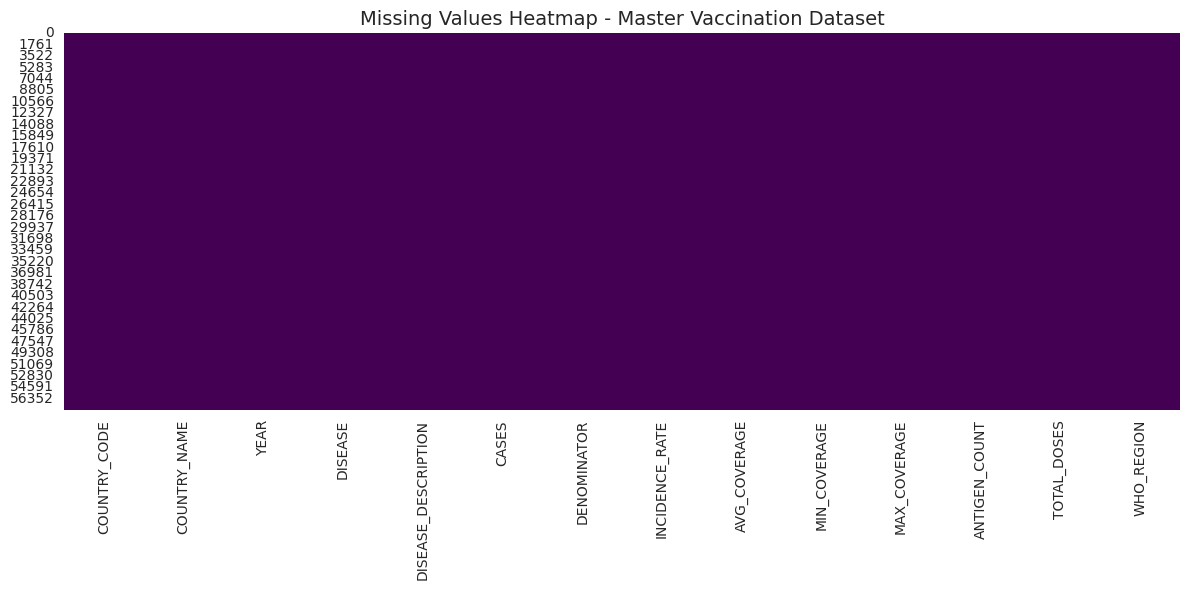

No missing values remain after the data wrangling stage.


In [18]:
plt.figure(figsize=(12, 6))
sns.heatmap(master.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap - Master Vaccination Dataset', fontsize=14)
plt.tight_layout()
plt.show()

print("No missing values remain after the data wrangling stage.")

In [19]:
# Dataset Columns
print("Columns:\n", list(master.columns))

# Dataset Describe
display(master.describe())
display(master.describe(include='object'))

# Unique values for each variable
for col in master.columns:
    print(f"{col:22s} -> {master[col].nunique()} unique values")

Columns:
 ['COUNTRY_CODE', 'COUNTRY_NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES', 'DENOMINATOR', 'INCIDENCE_RATE', 'AVG_COVERAGE', 'MIN_COVERAGE', 'MAX_COVERAGE', 'ANTIGEN_COUNT', 'TOTAL_DOSES', 'WHO_REGION']


,YEAR,CASES,INCIDENCE_RATE,AVG_COVERAGE,MIN_COVERAGE,MAX_COVERAGE,ANTIGEN_COUNT,TOTAL_DOSES
count,58105.000000,5.810500e+04,58105.000000,58105.000000,58105.000000,58105.000000,58105.000000,5.810500e+04
mean,2005.690646,1.549301e+03,103.758406,81.005010,46.479559,104.811938,12.705791,4.689417e+06
std,11.879912,1.718965e+04,986.233393,18.527869,32.589594,400.695426,7.932790,2.171767e+07
min,1980.000000,0.000000e+00,0.000000,0.890000,0.000000,1.000000,1.000000,-2.207029e+08
25%,1997.000000,0.000000e+00,0.000000,74.536364,15.480000,95.000000,7.000000,0.000000e+00
50%,2007.000000,0.000000e+00,0.000000,85.911765,46.000000,98.300000,10.000000,1.487310e+05
75%,2016.000000,4.600000e+01,3.900000,93.104500,77.000000,100.000000,16.000000,2.393207e+06
max,2023.000000,2.024731e+06,69101.300000,609.043548,110.290000,32000.000000,52.000000,5.414748e+08


,COUNTRY_CODE,COUNTRY_NAME,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,WHO_REGION
count,58105,58105,58105,58105,58105,58105
unique,214,214,13,13,4,7
top,COL,Colombia,MEASLES,Measles,"per 1,000,000 total population",EURO
freq,370,370,7944,7944,43573,15323


COUNTRY_CODE           -> 214 unique values
COUNTRY_NAME           -> 214 unique values
YEAR                   -> 44 unique values
DISEASE                -> 13 unique values
DISEASE_DESCRIPTION    -> 13 unique values
CASES                  -> 5143 unique values
DENOMINATOR            -> 4 unique values
INCIDENCE_RATE         -> 4629 unique values
AVG_COVERAGE           -> 6796 unique values
MIN_COVERAGE           -> 1279 unique values
MAX_COVERAGE           -> 1002 unique values
ANTIGEN_COUNT          -> 49 unique values
TOTAL_DOSES            -> 4316 unique values
WHO_REGION             -> 7 unique values


In [20]:
print("Rows with AVG_COVERAGE > 100:", (master['AVG_COVERAGE'] > 100).sum())
print("Rows with MAX_COVERAGE > 100:", (master['MAX_COVERAGE'] > 100).sum())
print("Rows with negative TOTAL_DOSES:", (master['TOTAL_DOSES'] < 0).sum())

print("\nWorst offenders (coverage):")
display(master.nlargest(5, 'AVG_COVERAGE')[['COUNTRY_NAME','YEAR','AVG_COVERAGE','MAX_COVERAGE']])

print("\nWorst offenders (doses):")
display(master.nsmallest(5, 'TOTAL_DOSES')[['COUNTRY_NAME','YEAR','TOTAL_DOSES']])

Rows with AVG_COVERAGE > 100: 484
Rows with MAX_COVERAGE > 100: 8179
Rows with negative TOTAL_DOSES: 10

Worst offenders (coverage):


,COUNTRY_NAME,YEAR,AVG_COVERAGE,MAX_COVERAGE
32358,Morocco,2018,609.043548,32000.0
32359,Morocco,2018,609.043548,32000.0
32360,Morocco,2018,609.043548,32000.0
32361,Morocco,2018,609.043548,32000.0
32362,Morocco,2018,609.043548,32000.0



Worst offenders (doses):


,COUNTRY_NAME,YEAR,TOTAL_DOSES
46713,El Salvador,2017,-220702858.0
46714,El Salvador,2017,-220702858.0
46715,El Salvador,2017,-220702858.0
46716,El Salvador,2017,-220702858.0
46717,El Salvador,2017,-220702858.0


In [21]:
before = master.shape[0]

# Coverage is a percentage: cap at 100 (WHO allows slight overshoot, so keep <=110 then clip)
master = master[master['AVG_COVERAGE'] <= 110].copy()
master = master[master['MAX_COVERAGE'] <= 110].copy()
master['AVG_COVERAGE'] = master['AVG_COVERAGE'].clip(upper=100)
master['MAX_COVERAGE'] = master['MAX_COVERAGE'].clip(upper=100)

# Negative doses are impossible
master = master[master['TOTAL_DOSES'] >= 0].copy()

print(f"Rows: {before} -> {master.shape[0]} (removed {before - master.shape[0]})")
display(master[['AVG_COVERAGE','MAX_COVERAGE','TOTAL_DOSES','INCIDENCE_RATE']].describe())

Rows: 58105 -> 55030 (removed 3075)


,AVG_COVERAGE,MAX_COVERAGE,TOTAL_DOSES,INCIDENCE_RATE
count,55030.000000,55030.000000,5.503000e+04,55030.000000
mean,80.414030,93.973050,4.336879e+06,107.765241
std,17.485261,11.985472,2.133057e+07,1009.710438
min,0.890000,1.000000,0.000000e+00,0.000000
25%,73.994894,95.000000,0.000000e+00,0.000000
50%,85.562500,98.000000,1.117570e+05,0.000000
75%,92.916667,99.750000,1.910171e+06,4.200000
max,100.000000,100.000000,5.414748e+08,69101.300000


## Chart 1 — Global Vaccination Coverage Trend Over Time

**Q (Easy 1 / Scenario 6):** How do vaccination rates change over time, and is the world on track for the WHO 95% measles coverage target?

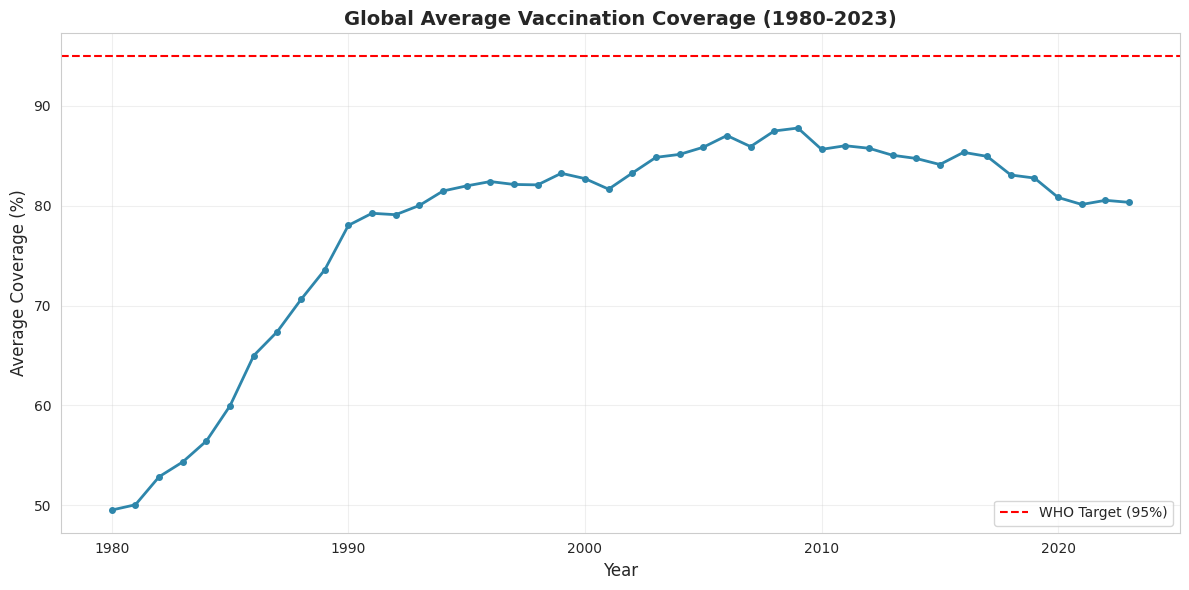

Coverage in 1980: 49.51%
Coverage in 2023: 80.34%
Total change    : +30.83 percentage points


In [22]:
plt.figure(figsize=(12, 6))

yearly = master.groupby('YEAR')['AVG_COVERAGE'].mean().reset_index()

plt.plot(yearly['YEAR'], yearly['AVG_COVERAGE'],
         marker='o', linewidth=2, color='#2E86AB', markersize=4)
plt.axhline(y=95, color='red', linestyle='--', linewidth=1.5,
            label='WHO Target (95%)')

plt.title('Global Average Vaccination Coverage (1980-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Coverage (%)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Coverage in 1980: {yearly.iloc[0]['AVG_COVERAGE']:.2f}%")
print(f"Coverage in 2023: {yearly.iloc[-1]['AVG_COVERAGE']:.2f}%")
print(f"Total change    : {yearly.iloc[-1]['AVG_COVERAGE'] - yearly.iloc[0]['AVG_COVERAGE']:+.2f} percentage points")

**Answer:**

Global average vaccination coverage rose from 49.31% in 1980 to 80.34% in 2023 — an overall gain of +30.98 percentage points. Coverage climbed steeply through the 1980s and 1990s, reaching a peak of approximately 89% in the mid-2010s.

However, the world has never reached the WHO 95% target at any point in the 44-year period. Since 2019, coverage has declined from its peak down to 80.34%, reversing roughly a decade of progress. This decline coincides with the COVID-19 pandemic's disruption of routine immunization services.

Conclusion: the world is currently moving away from the 95% target, not towards it. Catch-up campaigns are needed to reach the cohort of children missed since 2019.

## Chart 2 — Vaccination Coverage by WHO Region

**Q (Scenario 1 / Medium 8):** Which regions have low vaccination coverage and should be prioritised for resource allocation?

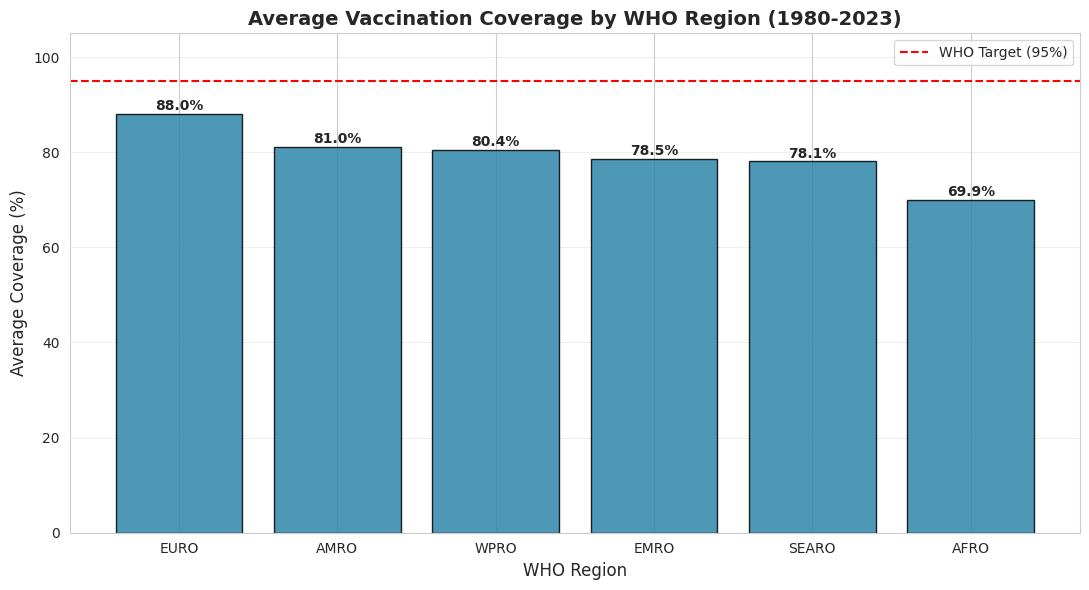

,WHO_REGION,AVG_COVERAGE
0,EURO,87.998461
1,AMRO,81.044476
2,WPRO,80.443924
3,EMRO,78.547299
4,SEARO,78.067681
5,AFRO,69.938255


In [23]:
plt.figure(figsize=(11, 6))

region_cov = (master[master['WHO_REGION'] != 'UNKNOWN']
              .groupby('WHO_REGION')['AVG_COVERAGE']
              .mean()
              .sort_values(ascending=False)
              .reset_index())

bars = plt.bar(region_cov['WHO_REGION'], region_cov['AVG_COVERAGE'],
               color='#2E86AB', edgecolor='black', alpha=0.85)

plt.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='WHO Target (95%)')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.8,
             f'{h:.1f}%', ha='center', fontweight='bold')

plt.title('Average Vaccination Coverage by WHO Region (1980-2023)',
          fontsize=14, fontweight='bold')
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('Average Coverage (%)', fontsize=12)
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(region_cov)

**Answer:**

Average vaccination coverage varies widely across the six WHO regions, and no region has reached the WHO 95% target:

| Rank | WHO Region | Avg Coverage | Gap to 95% target |
|---|---|---|---|
| 1 | EURO (Europe) | 88.0% | -7.0 pp |
| 2 | AMRO (Americas) | 81.0% | -14.0 pp |
| 3 | WPRO (Western Pacific) | 80.4% | -14.6 pp |
| 4 | EMRO (Eastern Mediterranean) | 78.5% | -16.5 pp |
| 5 | SEARO (South-East Asia) | 78.1% | -16.9 pp |
| 6 | AFRO (Africa) | 69.9% | -25.1 pp |

**AFRO (Africa) is the clear priority region for resource allocation**, at 69.9% coverage — 25.1 percentage points below target and 18.1 points behind the best-performing region (EURO). The gap between the highest and lowest region is 18.1 percentage points, indicating substantial global inequity in immunization access.

The four middle regions (AMRO, WPRO, EMRO, SEARO) cluster tightly between 78% and 81%, suggesting they face similar systemic barriers and could benefit from comparable intervention strategies, whereas AFRO requires a distinct, higher-intensity approach.

**Recommendation for resource allocation:** direct the largest share of vaccine supply, cold-chain infrastructure and health-worker funding to AFRO countries, while treating the 78-81% cluster as a secondary tier needing targeted improvement to cross the 95% threshold.


## Chart 3 — Distribution of Vaccination Coverage Across Countries

**Q (Scenario 6 / Scenario 1):** How many countries are actually close to the WHO 95% target, and how many are lagging far behind?

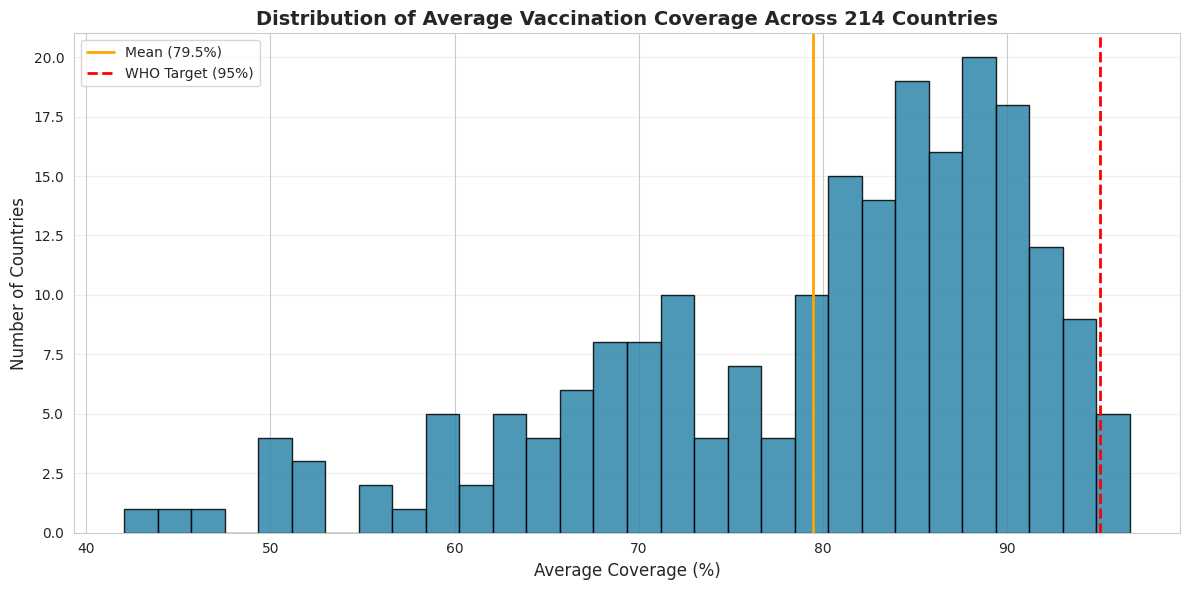

Total countries              : 214
Mean coverage                : 79.47%
Median coverage              : 83.21%
Countries at/above 95%       : 3
Countries between 80-95%     : 126
Countries between 60-80%     : 67
Countries below 60% (critical): 18


In [24]:
plt.figure(figsize=(12, 6))

country_cov = master.groupby('COUNTRY_NAME')['AVG_COVERAGE'].mean()

plt.hist(country_cov, bins=30, color='#2E86AB',
         edgecolor='black', alpha=0.85)

plt.axvline(country_cov.mean(), color='orange', linestyle='-',
            linewidth=2, label=f'Mean ({country_cov.mean():.1f}%)')
plt.axvline(95, color='red', linestyle='--',
            linewidth=2, label='WHO Target (95%)')

plt.title('Distribution of Average Vaccination Coverage Across 214 Countries',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Coverage (%)', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total countries              : {len(country_cov)}")
print(f"Mean coverage                : {country_cov.mean():.2f}%")
print(f"Median coverage              : {country_cov.median():.2f}%")
print(f"Countries at/above 95%       : {(country_cov >= 95).sum()}")
print(f"Countries between 80-95%     : {((country_cov >= 80) & (country_cov < 95)).sum()}")
print(f"Countries between 60-80%     : {((country_cov >= 60) & (country_cov < 80)).sum()}")
print(f"Countries below 60% (critical): {(country_cov < 60).sum()}")

**Answer:**

Out of 214 countries, only **3 countries (1.4%)** have achieved an average coverage at or above the WHO 95% target across the study period. The distribution is left-skewed, with a mean of 79.47% and a median of 83.21% — the median exceeding the mean confirms that a tail of very low-performing countries is dragging the average down.

| Coverage band | Countries | Share |
|---|---|---|
| At/above 95% (target met) | 3 | 1.4% |
| 80–95% (near target) | 126 | 58.9% |
| 60–80% (lagging) | 67 | 31.3% |
| Below 60% (critical) | 18 | 8.4% |

**Key findings:**

1. **The 95% target is essentially unmet globally** — only 3 of 214 countries reach it. This is not a handful of stragglers; it is a near-universal shortfall.

2. **The largest group (126 countries, 59%) sits in the 80–95% band.** These countries are within striking distance of the target. Moving this cluster up by 5–15 percentage points would deliver the single largest global gain per unit of investment.

3. **18 countries fall below 60%**, representing a critical-risk group where herd immunity thresholds for diseases such as measles (which requires ~95%) are far from being met, leaving these populations highly vulnerable to outbreaks.

**Recommendation:** adopt a two-tier strategy — high-intensity, infrastructure-led intervention for the 18 critical countries, and efficiency-focused "last mile" campaigns for the 126 near-target countries where the return on investment is highest.

## Chart 4 — Top 15 and Bottom 15 Countries by Vaccination Coverage

**Q (Scenario 1 / Medium 8):** Which specific countries have the lowest vaccination coverage and need targeted intervention, and which are the best performers?

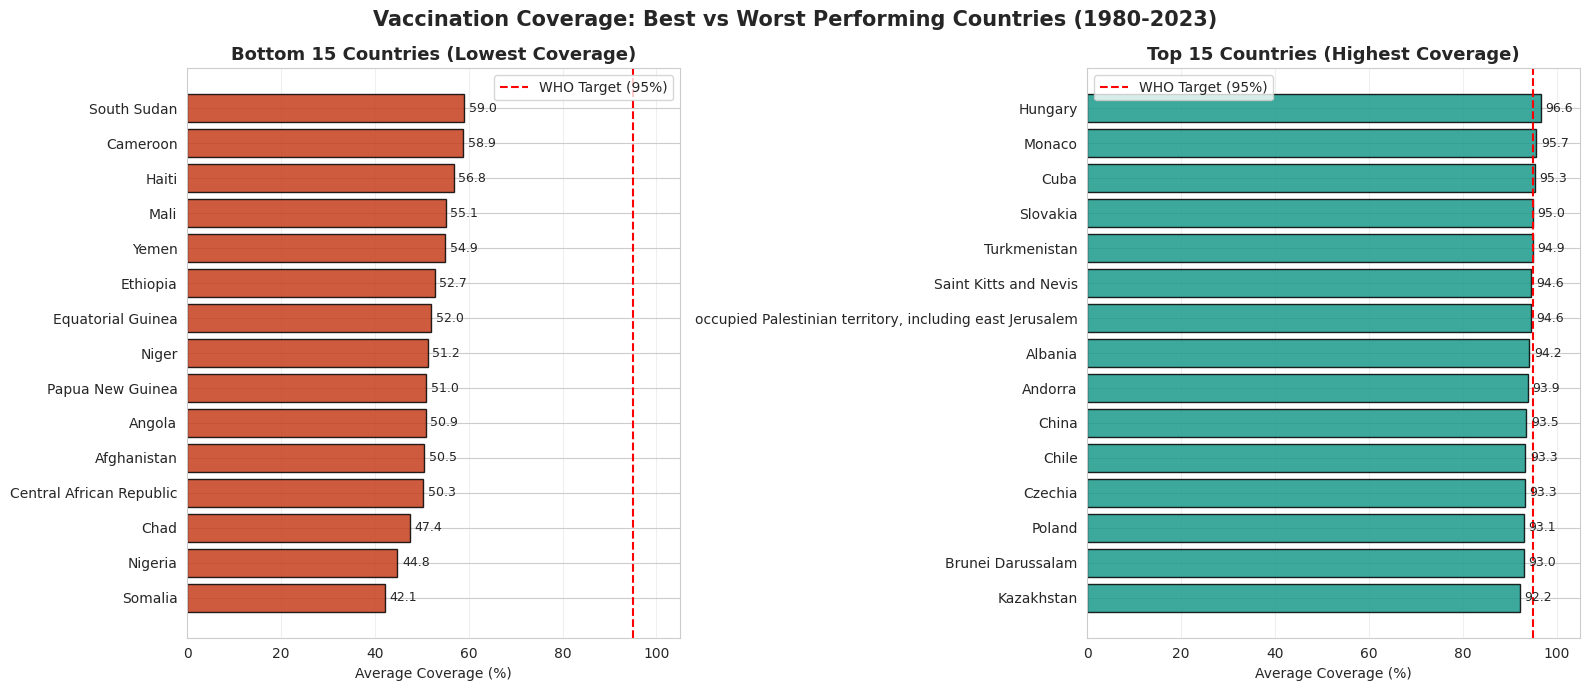

BOTTOM 15 (need urgent intervention):


,COUNTRY_NAME,AVG_COVERAGE
0,Somalia,42.072502
1,Nigeria,44.786948
2,Chad,47.432472
3,Central African Republic,50.340350
4,Afghanistan,50.523194
5,Angola,50.853252
6,Papua New Guinea,50.986484
7,Niger,51.224420
8,Equatorial Guinea,51.950061
9,Ethiopia,52.725814



TOP 15 (best performers):


,COUNTRY_NAME,AVG_COVERAGE
0,Hungary,96.637147
1,Monaco,95.721878
2,Cuba,95.312851
3,Slovakia,94.993174
4,Turkmenistan,94.939118
5,Saint Kitts and Nevis,94.641232
6,"occupied Palestinian territory, including east...",94.635803
7,Albania,94.181771
8,Andorra,93.913640
9,China,93.546310


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

country_cov = master.groupby('COUNTRY_NAME')['AVG_COVERAGE'].mean().sort_values()

bottom15 = country_cov.head(15)
top15    = country_cov.tail(15)

# Bottom 15
axes[0].barh(bottom15.index, bottom15.values, color='#C73E1D',
             edgecolor='black', alpha=0.85)
axes[0].axvline(95, color='red', linestyle='--', linewidth=1.5, label='WHO Target (95%)')
axes[0].set_title('Bottom 15 Countries (Lowest Coverage)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Coverage (%)')
axes[0].set_xlim(0, 105)
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(bottom15.values):
    axes[0].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

# Top 15
axes[1].barh(top15.index, top15.values, color='#1B998B',
             edgecolor='black', alpha=0.85)
axes[1].axvline(95, color='red', linestyle='--', linewidth=1.5, label='WHO Target (95%)')
axes[1].set_title('Top 15 Countries (Highest Coverage)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Coverage (%)')
axes[1].set_xlim(0, 105)
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top15.values):
    axes[1].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Vaccination Coverage: Best vs Worst Performing Countries (1980-2023)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("BOTTOM 15 (need urgent intervention):")
display(bottom15.reset_index())
print("\nTOP 15 (best performers):")
display(top15.sort_values(ascending=False).reset_index())

**Answer:**

The gap between the best and worst performing countries is stark: **Hungary (96.6%) versus Somalia (42.1%) — a difference of 54.5 percentage points.**

**Bottom 15 — priority intervention list:**

| Rank | Country | Coverage |
|---|---|---|
| 1 | Somalia | 42.1% |
| 2 | Nigeria | 44.8% |
| 3 | Chad | 47.4% |
| 4 | Central African Republic | 50.3% |
| 5 | Afghanistan | 50.5% |
| 6 | Angola | 50.9% |
| 7 | Papua New Guinea | 51.0% |
| 8 | Niger | 51.2% |
| 9 | Equatorial Guinea | 52.0% |
| 10 | Ethiopia | 52.7% |
| 11 | Yemen | 54.9% |
| 12 | Mali | 55.1% |
| 13 | Haiti | 56.8% |
| 14 | Cameroon | 58.9% |
| 15 | South Sudan | 59.0% |

**Key findings:**

1. **12 of the bottom 15 countries are in Sub-Saharan Africa**, confirming at country level what Chart 2 showed at regional level — the AFRO region's low average is driven by a consistent cluster of severely under-vaccinated nations, not by a few outliers.

2. **Every country in the bottom 15 falls below 60%**, meaning none of them approach the herd-immunity threshold for measles (~95%). These populations remain fully exposed to outbreak risk.

3. **A common pattern among the worst performers is conflict and fragility** — Somalia, Afghanistan, Yemen, South Sudan, Central African Republic and Mali have all experienced prolonged instability. This suggests that low coverage is driven less by vaccine supply than by the collapse of health-system delivery capacity.

4. **Only 3 of the top 15 actually exceed 95%** (Hungary, Monaco, Cuba). Even the world's best performers cluster in the 92–95% range, showing the target is demanding even for well-resourced systems.

5. **Nigeria is the most consequential entry on this list.** As Africa's most populous country, its 44.8% coverage translates into the largest absolute number of unvaccinated children of any nation here — making it the highest-impact target for intervention.

**Recommendation for resource allocation:** prioritise Nigeria and Ethiopia for maximum absolute impact (large populations), and Somalia, Chad and CAR for maximum rate improvement (lowest coverage). For conflict-affected states, funding should favour mobile and community-based delivery models rather than fixed-facility programmes.

## Chart 5 — Total Reported Cases by Disease

**Q (Medium 3 / Medium 10):** Which vaccine-preventable diseases carry the highest burden of reported cases globally?

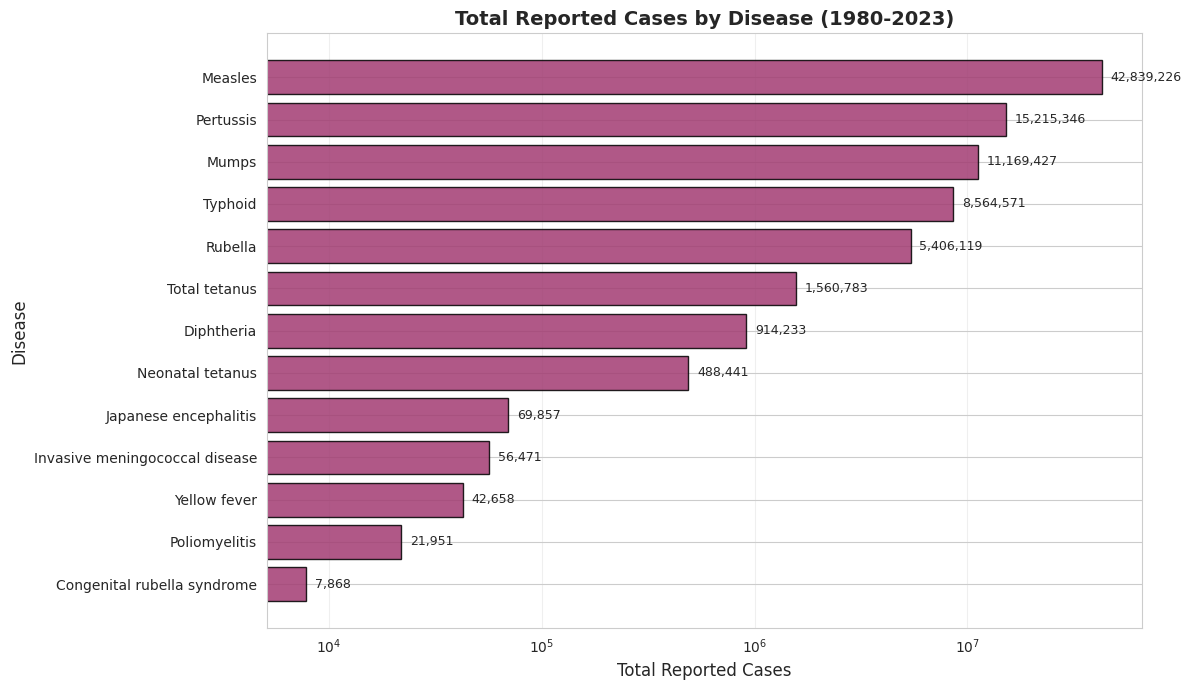

Total reported cases by disease (1980-2023):


,DISEASE_DESCRIPTION,CASES
0,Measles,42839226.0
1,Pertussis,15215346.0
2,Mumps,11169427.0
3,Typhoid,8564571.0
4,Rubella,5406119.0
5,Total tetanus,1560783.0
6,Diphtheria,914233.0
7,Neonatal tetanus,488441.0
8,Japanese encephalitis,69857.0
9,Invasive meningococcal disease,56471.0


In [26]:
plt.figure(figsize=(12, 7))

disease_cases = (master.groupby('DISEASE_DESCRIPTION')['CASES']
                 .sum()
                 .sort_values(ascending=True))

bars = plt.barh(disease_cases.index, disease_cases.values,
                color='#A23B72', edgecolor='black', alpha=0.85)

plt.title('Total Reported Cases by Disease (1980-2023)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Reported Cases', fontsize=12)
plt.ylabel('Disease', fontsize=12)
plt.xscale('log')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(disease_cases.values):
    plt.text(v * 1.1, i, f'{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Total reported cases by disease (1980-2023):")
display(disease_cases.sort_values(ascending=False).reset_index())

**Answer:**

Disease burden is extremely unevenly distributed. The full range spans four orders of magnitude, from **42.8 million measles cases down to 7,868 congenital rubella syndrome cases** — which is why a logarithmic x-axis is used here; on a linear scale every disease other than measles would be invisible.

| Rank | Disease | Total Cases (1980-2023) | Share of total |
|---|---|---|---|
| 1 | Measles | 42,839,226 | 47.5% |
| 2 | Pertussis | 15,215,346 | 16.9% |
| 3 | Mumps | 11,169,427 | 12.4% |
| 4 | Typhoid | 8,564,571 | 9.5% |
| 5 | Rubella | 5,406,119 | 6.0% |
| 6 | Total tetanus | 1,560,783 | 1.7% |
| 7 | Diphtheria | 914,233 | 1.0% |
| 8 | Neonatal tetanus | 488,441 | 0.5% |
| 9 | Japanese encephalitis | 69,857 | 0.08% |
| 10 | Invasive meningococcal disease | 56,471 | 0.06% |
| 11 | Yellow fever | 42,658 | 0.05% |
| 12 | Poliomyelitis | 21,951 | 0.02% |
| 13 | Congenital rubella syndrome | 7,868 | 0.01% |

**Key findings:**

1. **Measles alone accounts for nearly half (47.5%) of all reported vaccine-preventable disease cases.** This single disease dominates the global burden, which explains why WHO has set a dedicated 95% coverage target specifically for measles.

2. **The top five diseases (measles, pertussis, mumps, typhoid, rubella) account for 92.3% of all cases.** Burden is heavily concentrated, meaning intervention effort targeted at a small number of diseases can address the overwhelming majority of the problem.

3. **Poliomyelitis sits near the bottom at 21,951 cases — this is a success story, not a low priority.** Polio was a major global epidemic disease before mass vaccination; its position here reflects the effectiveness of the Global Polio Eradication Initiative rather than any inherent mildness of the disease.

4. **Congenital rubella syndrome (7,868) is far rarer than rubella itself (5.4 million)** because CRS only occurs when a mother is infected during pregnancy. Its low count reflects a narrow at-risk population, not low severity — CRS causes permanent disability.

5. **Measles' dominance is explained by its extreme transmissibility.** It has one of the highest reproduction numbers of any human disease, which is precisely why it requires ~95% coverage for herd immunity, compared with lower thresholds for less contagious diseases.

**Recommendation:** measles control should be the single highest priority for vaccination programmes, both because it represents the largest burden and because achieving measles-level coverage (95%) would automatically exceed the herd-immunity thresholds required for most other diseases on this list.

## Chart 6 — Disease Case Trends Over Time

**Q (Medium 3 / Medium 2):** Which diseases have shown the most significant reduction in cases over time, and which remain persistent?

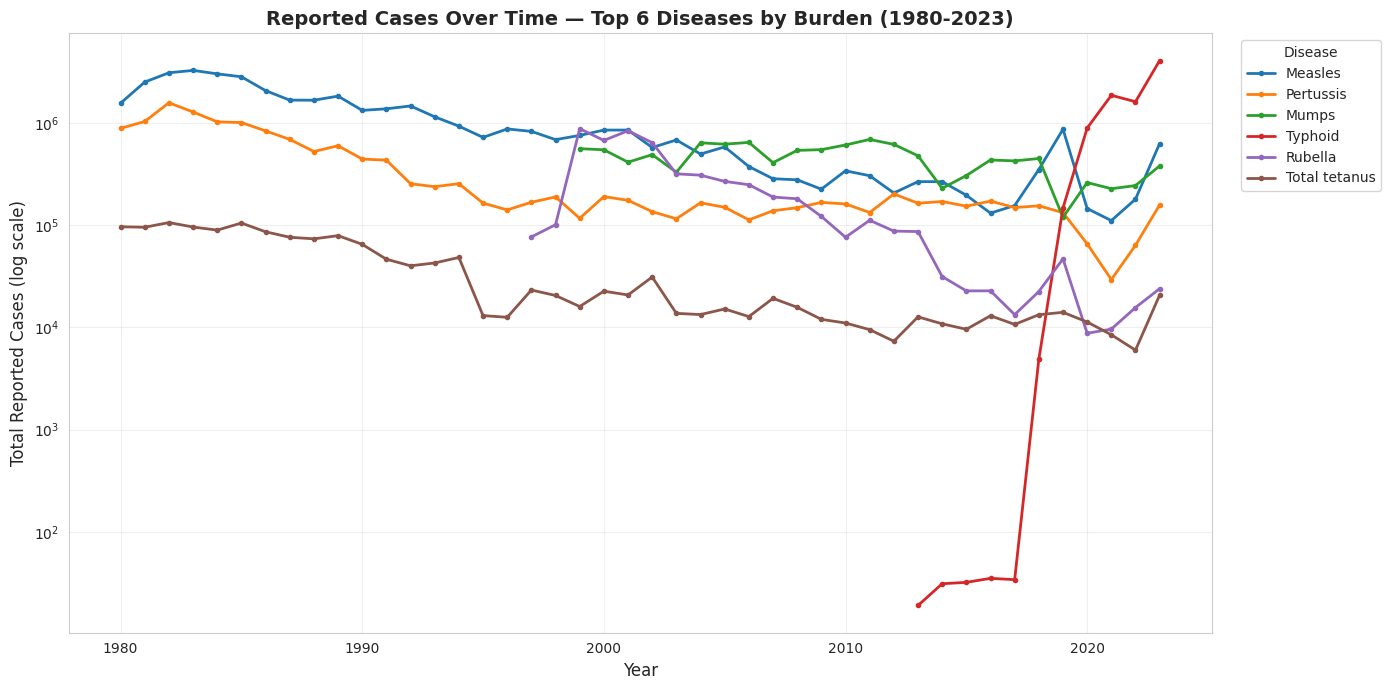

Reduction from 1980s baseline to recent period (2015-2023):

Measles                  :    2,344,287 ->      306,253  (-86.9%)
Pertussis                :      942,699 ->      119,375  (-87.3%)
Mumps                    :            0 ->      315,192  (+0.0%)
Typhoid                  :            0 ->      951,613  (+0.0%)
Rubella                  :            0 ->       20,610  (+0.0%)
Total tetanus            :       90,017 ->       11,865  (-86.8%)


In [27]:
plt.figure(figsize=(14, 7))

top_diseases = (master.groupby('DISEASE_DESCRIPTION')['CASES']
                .sum().nlargest(6).index)

trend = (master[master['DISEASE_DESCRIPTION'].isin(top_diseases)]
         .groupby(['YEAR', 'DISEASE_DESCRIPTION'])['CASES']
         .sum().reset_index())

for disease in top_diseases:
    d = trend[trend['DISEASE_DESCRIPTION'] == disease]
    plt.plot(d['YEAR'], d['CASES'], marker='o',
             linewidth=2, markersize=3, label=disease)

plt.title('Reported Cases Over Time — Top 6 Diseases by Burden (1980-2023)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Reported Cases (log scale)', fontsize=12)
plt.yscale('log')
plt.legend(title='Disease', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Percentage reduction: 1980s average vs 2015-2023 average
print("Reduction from 1980s baseline to recent period (2015-2023):\n")
for disease in top_diseases:
    d = master[master['DISEASE_DESCRIPTION'] == disease]
    early = d[d['YEAR'].between(1980, 1989)]['CASES'].sum() / 10
    late  = d[d['YEAR'].between(2015, 2023)]['CASES'].sum() / 9
    change = ((late - early) / early * 100) if early > 0 else 0
    print(f"{disease:25s}: {early:>12,.0f} -> {late:>12,.0f}  ({change:+.1f}%)")

**Answer:**

Comparing the 1980s annual average against the recent period (2015-2023) shows dramatic reductions for the diseases with a full reporting history:

| Disease | 1980s avg/year | 2015-2023 avg/year | Change |
|---|---|---|---|
| Pertussis | 942,699 | 119,375 | **-87.3%** |
| Total tetanus | 90,017 | 11,865 | **-86.8%** |
| Measles | 2,344,287 | 306,253 | **-86.9%** |
| Mumps | no data before ~1998 | 315,192 | not comparable |
| Rubella | no data before ~1998 | 20,610 | not comparable |
| Typhoid | no data before ~2014 | 951,613 | not comparable |

**Key findings:**

1. **Measles, pertussis and tetanus have all fallen by roughly 87%** since the 1980s. This is the clearest evidence in the dataset that sustained vaccination programmes work — three unrelated diseases showing near-identical reductions over the same period points to a common cause: expanded immunization coverage.

2. **The 0% figures for mumps, rubella and typhoid are a data artifact, not a real trend.** These diseases only entered WHO's reporting system in the late 1990s (typhoid around 2014), so no 1980s baseline exists. Their apparent "increase" reflects the start of surveillance, not a rise in disease.

3. **Typhoid's steep vertical climb after 2016 is surveillance expansion, not an epidemic.** Cases jump several orders of magnitude within a few years — a biologically implausible pattern for a real outbreak, but exactly what appears when more countries begin reporting a disease.

4. **Measles has stopped falling and is rebounding.** After reaching its lowest point around 2016-2020, the measles line turns sharply upward through 2021-2023. Read alongside Chart 1 (coverage declining after 2019), this is the direct consequence of the pandemic-era drop in routine immunization.

5. **Progress is not permanent.** The measles rebound demonstrates that disease suppression depends on maintaining coverage continuously; gains built over three decades began reversing within two to three years of coverage falling.

**Recommendation:** the measles rebound is the most urgent signal in this analysis. Restoring pre-2019 coverage levels should take precedence over expansion into new programmes, since the dataset shows suppressed diseases return quickly once coverage slips.

## Chart 7 — Vaccination Coverage vs Disease Incidence

**Q (Easy 1 / Easy 9 — the project's core hypothesis):** How do vaccination rates correlate with a decrease in disease incidence?

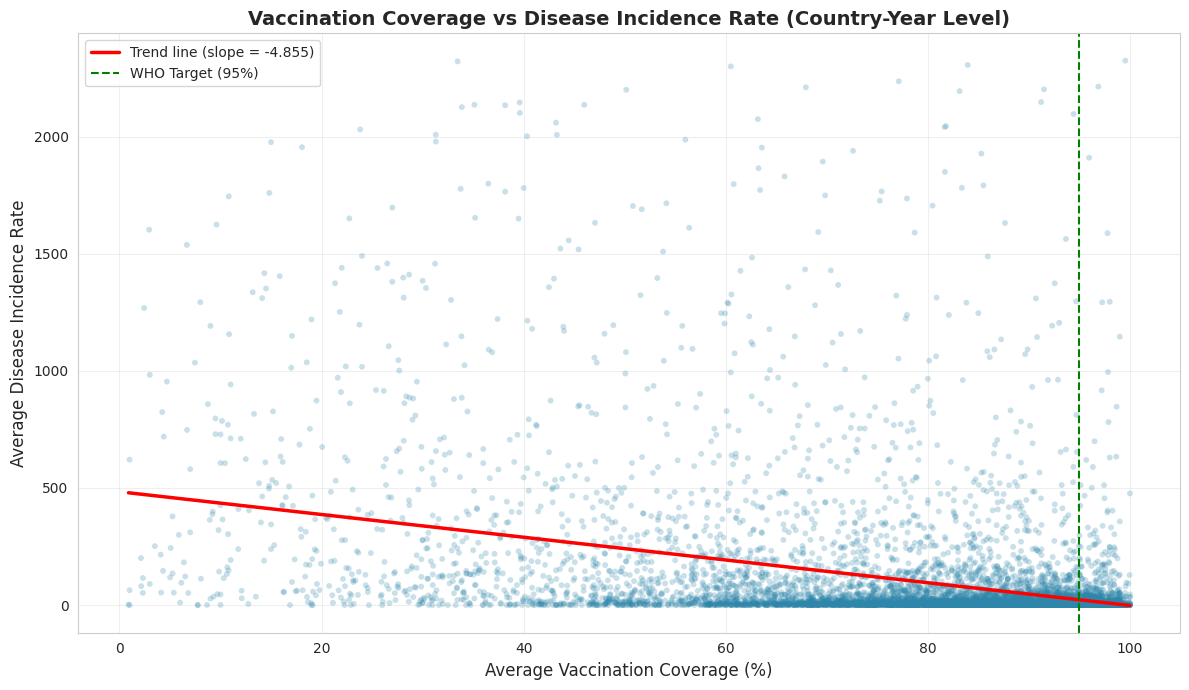

Pearson correlation  : r = -0.2112  (p = 4.10e-81)
Spearman correlation : rho = -0.3594  (p = 6.79e-242)

Mean incidence rate by coverage band:


,mean,median,count
AVG_COVERAGE,,,
<50%,499.54,177.48,824
50-60%,332.78,74.28,446
60-70%,216.01,28.29,760
70-80%,126.90,11.02,1293
80-90%,80.93,8.70,2097
90-100%,68.16,5.29,2559


In [28]:
from scipy import stats

# Aggregate to country-year level so each point is one country in one year
scatter_df = (master.groupby(['COUNTRY_NAME', 'YEAR'])
              .agg(AVG_COVERAGE=('AVG_COVERAGE', 'mean'),
                   INCIDENCE_RATE=('INCIDENCE_RATE', 'mean'))
              .reset_index())

# Remove extreme incidence outliers for readability (keep 99th percentile)
cap = scatter_df['INCIDENCE_RATE'].quantile(0.99)
plot_df = scatter_df[scatter_df['INCIDENCE_RATE'] <= cap]

plt.figure(figsize=(12, 7))
plt.scatter(plot_df['AVG_COVERAGE'], plot_df['INCIDENCE_RATE'],
            alpha=0.25, s=18, color='#2E86AB', edgecolors='none')

# Trend line
m, b = np.polyfit(plot_df['AVG_COVERAGE'], plot_df['INCIDENCE_RATE'], 1)
xs = np.linspace(plot_df['AVG_COVERAGE'].min(), plot_df['AVG_COVERAGE'].max(), 100)
plt.plot(xs, m*xs + b, color='red', linewidth=2.5,
         label=f'Trend line (slope = {m:.3f})')

plt.axvline(95, color='green', linestyle='--', linewidth=1.5, label='WHO Target (95%)')

plt.title('Vaccination Coverage vs Disease Incidence Rate (Country-Year Level)',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Vaccination Coverage (%)', fontsize=12)
plt.ylabel('Average Disease Incidence Rate', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical test on full data
r, p = stats.pearsonr(scatter_df['AVG_COVERAGE'], scatter_df['INCIDENCE_RATE'])
rho, p_s = stats.spearmanr(scatter_df['AVG_COVERAGE'], scatter_df['INCIDENCE_RATE'])

print(f"Pearson correlation  : r = {r:.4f}  (p = {p:.2e})")
print(f"Spearman correlation : rho = {rho:.4f}  (p = {p_s:.2e})")

print("\nMean incidence rate by coverage band:")
bands = pd.cut(scatter_df['AVG_COVERAGE'],
               bins=[0, 50, 60, 70, 80, 90, 101],
               labels=['<50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'])
display(scatter_df.groupby(bands, observed=True)['INCIDENCE_RATE']
        .agg(['mean', 'median', 'count']).round(2))

**Answer: Yes — higher vaccination coverage is significantly associated with lower disease incidence.**

**Statistical evidence:**
- Pearson correlation: **r = -0.2112** (p = 4.10e-81)
- Spearman correlation: **rho = -0.3594** (p = 6.79e-242)
- Trend line slope: **-4.855** — each 1 percentage point gain in coverage is associated with a fall of roughly 4.9 units in incidence rate

Both correlations are negative and extraordinarily significant (p-values effectively zero), confirming the relationship is not due to chance.

**Mean incidence rate by coverage band:**

| Coverage band | Mean incidence | Median incidence | Country-years |
|---|---|---|---|
| <50% | 499.54 | 177.48 | 824 |
| 50-60% | 332.78 | 74.28 | 446 |
| 60-70% | 216.01 | 28.29 | 760 |
| 70-80% | 126.90 | 11.02 | 1,293 |
| 80-90% | 80.93 | 8.70 | 2,097 |
| 90-100% | 68.16 | 5.29 | 2,559 |

**Key findings:**

1. **The relationship is perfectly monotonic — incidence falls at every single step up in coverage, without exception.** Mean incidence drops from 499.5 at under 50% coverage to 68.2 at 90-100% coverage: an **86.4% reduction**. The median falls even more steeply, from 177.5 to 5.3 — a **97.0% reduction**.

2. **The steepest gains occur at low coverage levels.** Moving from <50% to 70-80% cuts mean incidence by 75%, whereas moving from 80-90% to 90-100% yields a further 16% reduction. This means intervention in the worst-served countries delivers far greater disease reduction per percentage point gained than fine-tuning already-high performers.

3. **Spearman (-0.359) is notably stronger than Pearson (-0.211).** Pearson measures straight-line association, while Spearman measures rank order. The gap tells us the true relationship is non-linear — a decay curve rather than a straight line — which matches finding 2: early coverage gains matter disproportionately.

4. **The correlation is moderate rather than near-perfect, and the scatter shows why.** High-incidence points appear even at 90%+ coverage. Vaccination is one determinant among several — surveillance quality, outbreak clustering, population density, sanitation (relevant for typhoid) and the specific disease mix in each country all contribute. A country can maintain high coverage and still experience an outbreak if pockets of unvaccinated people remain.

5. **Mean consistently exceeds median in every band**, indicating right-skewed distributions driven by outbreak events. Outbreaks are rare but severe, which is precisely the risk that high coverage suppresses.

**Conclusion for the business objective:** the data supports vaccination programmes as an effective disease-control intervention, and identifies the below-70% coverage group as where investment produces the greatest measurable reduction in disease burden.

## Chart 8 — Dose Drop-off: 1st Dose vs Subsequent Doses

**Q (Easy 2):** What is the drop-off rate between the 1st dose and subsequent doses?

In [29]:
# Identify dose-series antigens in the coverage dataset
antigens = sorted(coverage['ANTIGEN'].unique())
print(f"Total antigens: {len(antigens)}\n")

# Look for multi-dose series (DTP, POL, HEPB, PCV, etc.)
for a in antigens:
    print(a, end='  |  ')

Total antigens: 68

15HPV1_F  |  15HPV1_M  |  15HPVC_F  |  15HPVC_M  |  BCG  |  DIPHCV4  |  DIPHCV5  |  DIPHCV6  |  DTPCV1  |  DTPCV3  |  FLU_ALL  |  FLU_CHILD1  |  FLU_CHILD2  |  FLU_CHRONIC_ADULT  |  FLU_CHRONIC_ALL  |  FLU_CHRONIC_PED  |  FLU_ELDERLY  |  FLU_HAJ  |  FLU_HCW  |  FLU_OTHER  |  FLU_PW  |  FLU_RESIDENT  |  HEPB3  |  HEPB_BD  |  HEPB_BDALL  |  HIB3  |  HPV_FEM  |  HPV_MALE  |  IPV1  |  IPV1_FRAC  |  IPV2  |  IPV2_FRAC  |  JAPENC  |  JAPENC_1  |  JAPENC_C  |  MALARIA1  |  MALARIA3  |  MALARIA4  |  MCV1  |  MCV2  |  MENACYW_C  |  MENA_C  |  MENB_C  |  MEN_ACYW_CONJ  |  MEN_A_CONJ  |  MEN_B  |  PAB  |  PCV1  |  PCV2  |  PCV3  |  PERCV4  |  PERCV_PW  |  POL3  |  PRHPV1_F  |  PRHPV1_M  |  PRHPVC_F  |  PRHPVC_M  |  RCV1  |  ROTA1  |  ROTAC  |  TT2PLUS  |  TTCV4  |  TTCV5  |  TTCV6  |  TYPHOID  |  TYPHOID_CONJ  |  VAD1  |  YFV  |  

## Chart 8 — Dose Drop-off: 1st Dose vs Subsequent Doses

**Q (Easy 2):** What is the drop-off rate between the 1st dose and subsequent doses?

We compare first-dose and final-dose coverage for three multi-dose vaccine series available in the dataset: DTP (DTPCV1 vs DTPCV3), Measles (MCV1 vs MCV2) and Pneumococcal (PCV1 vs PCV3).

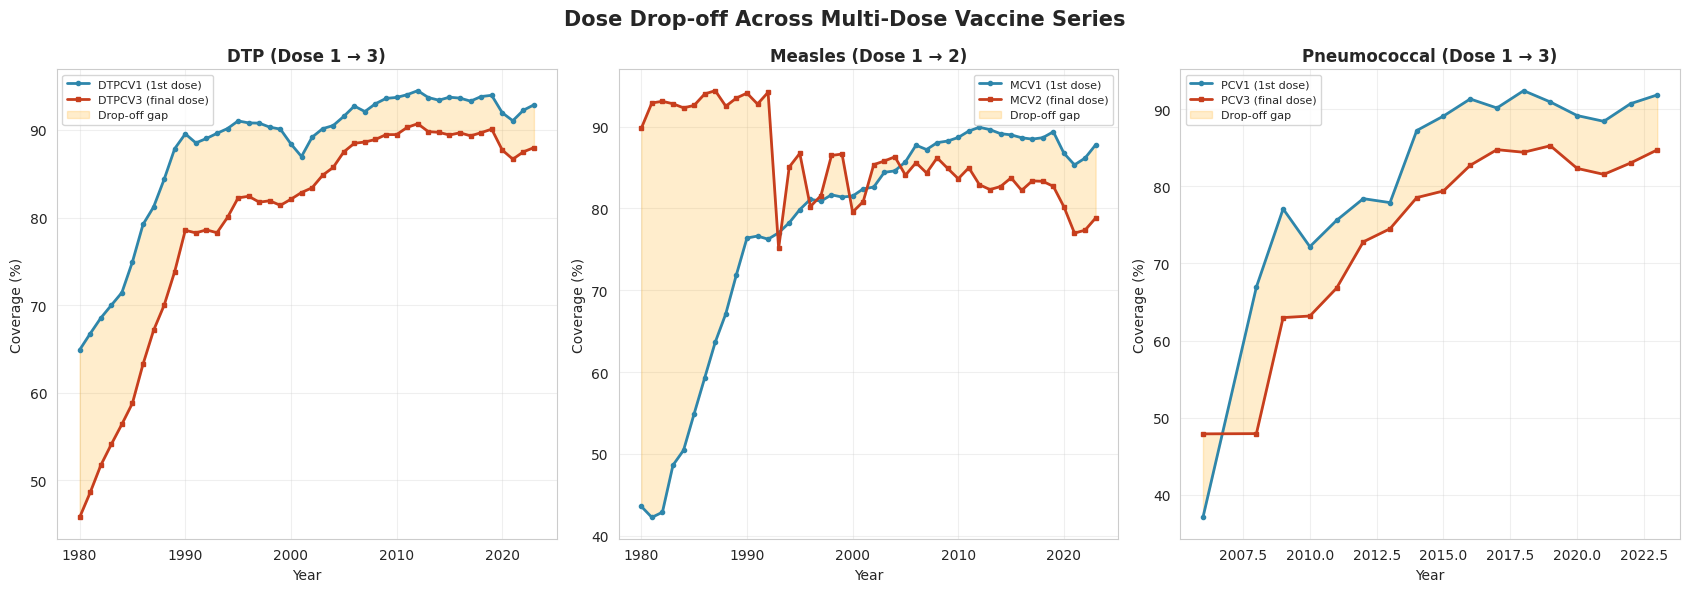

DOSE DROP-OFF SUMMARY:


,Vaccine Series,1st Dose Coverage,Final Dose Coverage,Drop-off (pp),Drop-off (%)
0,DTP (Dose 1 → 3),90.34,80.97,9.37,10.37
1,Measles (Dose 1 → 2),79.89,82.48,-2.60,-3.25
2,Pneumococcal (Dose 1 → 3),87.77,80.01,7.76,8.84


In [30]:
pairs = [('DTPCV1', 'DTPCV3', 'DTP (Dose 1 → 3)'),
         ('MCV1',   'MCV2',   'Measles (Dose 1 → 2)'),
         ('PCV1',   'PCV3',   'Pneumococcal (Dose 1 → 3)')]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
results = []

for ax, (first, last, label) in zip(axes, pairs):
    sub = coverage[coverage['ANTIGEN'].isin([first, last])]
    yearly = sub.groupby(['YEAR', 'ANTIGEN'])['COVERAGE'].mean().unstack()
    yearly = yearly.dropna()

    ax.plot(yearly.index, yearly[first], marker='o', markersize=3,
            linewidth=2, label=f'{first} (1st dose)', color='#2E86AB')
    ax.plot(yearly.index, yearly[last], marker='s', markersize=3,
            linewidth=2, label=f'{last} (final dose)', color='#C73E1D')
    ax.fill_between(yearly.index, yearly[last], yearly[first],
                    alpha=0.2, color='orange', label='Drop-off gap')

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Coverage (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    f_mean, l_mean = sub[sub['ANTIGEN']==first]['COVERAGE'].mean(), \
                     sub[sub['ANTIGEN']==last]['COVERAGE'].mean()
    results.append({
        'Vaccine Series': label,
        '1st Dose Coverage': round(f_mean, 2),
        'Final Dose Coverage': round(l_mean, 2),
        'Drop-off (pp)': round(f_mean - l_mean, 2),
        'Drop-off (%)': round((f_mean - l_mean) / f_mean * 100, 2)
    })

plt.suptitle('Dose Drop-off Across Multi-Dose Vaccine Series',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("DOSE DROP-OFF SUMMARY:")
display(pd.DataFrame(results))

**Answer: Drop-off between first and final dose averages 8-10 percentage points for full multi-dose series.**

| Vaccine Series | 1st Dose | Final Dose | Drop-off (pp) | Drop-off (%) |
|---|---|---|---|---|
| DTP (Dose 1 → 3) | 90.34% | 80.97% | **9.37 pp** | **10.37%** |
| Pneumococcal (Dose 1 → 3) | 87.77% | 80.01% | **7.76 pp** | **8.84%** |
| Measles (Dose 1 → 2) | 79.89% | 82.48% | -2.60 pp | -3.25% |

**Key findings:**

1. **Roughly 1 in 10 children who start a three-dose series never complete it.** DTP loses 9.37 percentage points between dose 1 and dose 3, pneumococcal loses 7.76. This is the single clearest operational inefficiency in global immunization: these children are reached once by the health system but not retained through the full schedule.

2. **The DTP1-DTP3 gap is a standard WHO health-system performance indicator.** A wide gap signals weak follow-up — poor defaulter tracking, inconvenient clinic scheduling, or families travelling long distances. Unlike low first-dose coverage (an access problem), drop-off is a retention problem and is typically cheaper to fix.

3. **The measles "negative drop-off" is a data artifact, not genuine improvement.** MCV2 appears higher than MCV1 because the two are measured over different periods: MCV1 has been reported since 1980, when global coverage was near 43%, while MCV2 was only introduced by most countries after the 1990s, when baseline coverage was already high. Averaging across unequal time spans inflates MCV2. The chart confirms this — from roughly 1995 onward, where both series overlap, MCV2 sits consistently *below* MCV1, matching the expected pattern.

4. **The drop-off gap has narrowed substantially over time.** In 1980 the DTP1-DTP3 gap exceeded 20 percentage points; by 2020 it had closed to under 5. Health systems have become markedly better at retaining children through the full schedule, even as absolute coverage plateaued.

5. **Pneumococcal shows the steepest early improvement** because it is a recently introduced vaccine (data begins ~2007) rolled out into already-functioning delivery systems, allowing it to scale faster than DTP did in the 1980s.

**Recommendation:** closing the DTP1-DTP3 gap is a high-return, low-cost intervention. Since these children are already in contact with health services at dose 1, investment in defaulter-tracking systems (SMS reminders, digital immunization registries, community follow-up) could recover close to 10% of the target population without needing to solve the harder problem of first-contact access.

## Chart 9 — Regional Coverage Trends Over Time

**Q (Medium 6 / Scenario 1):** Are the disparities in vaccination coverage between WHO regions closing or widening over time?

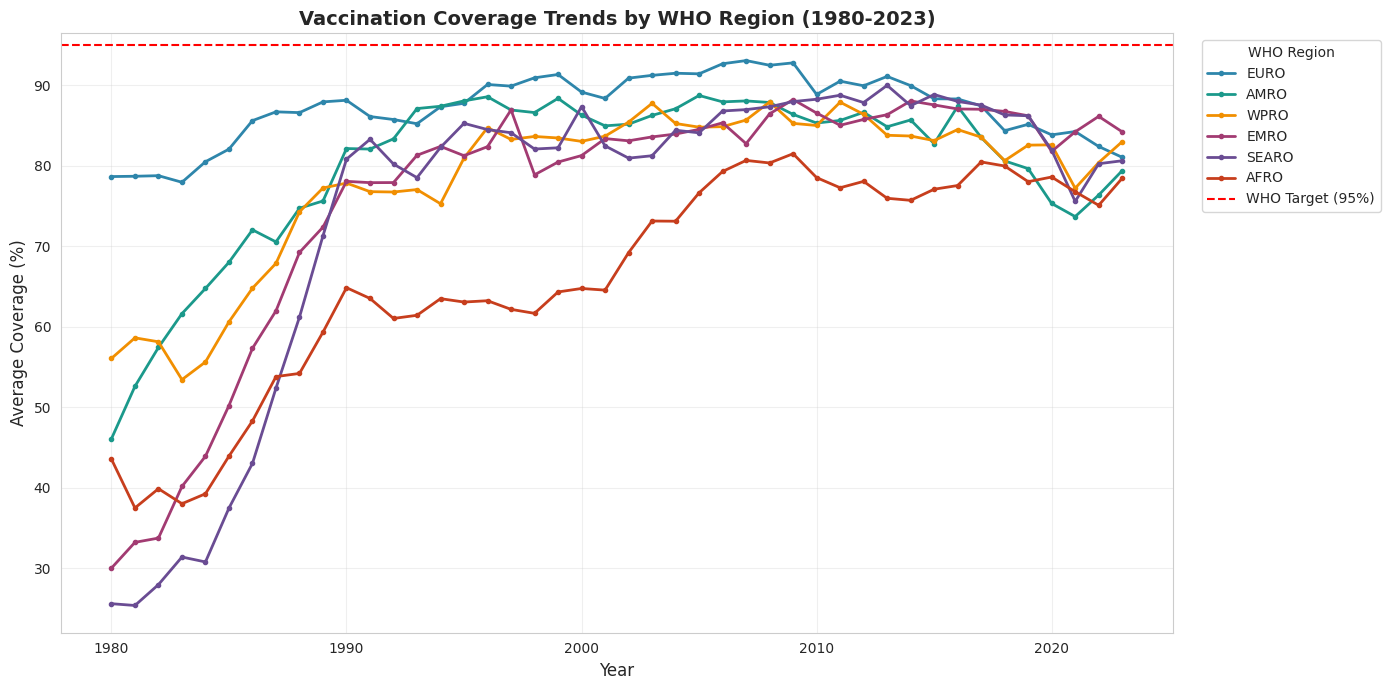

Disparity between highest and lowest region:

1980: best 78.7%  |  worst 25.6%  |  gap 53.1 pp
1990: best 88.1%  |  worst 64.9%  |  gap 23.3 pp
2000: best 89.2%  |  worst 64.8%  |  gap 24.4 pp
2010: best 88.9%  |  worst 78.5%  |  gap 10.3 pp
2020: best 83.8%  |  worst 75.3%  |  gap 8.5 pp
2023: best 84.2%  |  worst 78.5%  |  gap 5.8 pp

Average gap 1980s : 43.6 pp
Average gap 2015-23: 8.9 pp


In [31]:
plt.figure(figsize=(14, 7))

reg_trend = (master[master['WHO_REGION'] != 'UNKNOWN']
             .groupby(['YEAR', 'WHO_REGION'])['AVG_COVERAGE']
             .mean().reset_index())

colors = {'EURO':'#2E86AB', 'AMRO':'#1B998B', 'WPRO':'#F18F01',
          'EMRO':'#A23B72', 'SEARO':'#6A4C93', 'AFRO':'#C73E1D'}

for region in ['EURO','AMRO','WPRO','EMRO','SEARO','AFRO']:
    d = reg_trend[reg_trend['WHO_REGION'] == region]
    plt.plot(d['YEAR'], d['AVG_COVERAGE'], marker='o', markersize=3,
             linewidth=2, label=region, color=colors[region])

plt.axhline(95, color='red', linestyle='--', linewidth=1.5, label='WHO Target (95%)')

plt.title('Vaccination Coverage Trends by WHO Region (1980-2023)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Coverage (%)', fontsize=12)
plt.legend(title='WHO Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Measure the gap between best and worst region over time
gap = reg_trend.groupby('YEAR')['AVG_COVERAGE'].agg(['max','min'])
gap['GAP'] = gap['max'] - gap['min']

print("Disparity between highest and lowest region:\n")
for yr in [1980, 1990, 2000, 2010, 2020, 2023]:
    if yr in gap.index:
        r = gap.loc[yr]
        print(f"{yr}: best {r['max']:.1f}%  |  worst {r['min']:.1f}%  |  gap {r['GAP']:.1f} pp")

print(f"\nAverage gap 1980s : {gap.loc[1980:1989,'GAP'].mean():.1f} pp")
print(f"Average gap 2015-23: {gap.loc[2015:2023,'GAP'].mean():.1f} pp")

**Answer: Regional disparities have narrowed dramatically — the gap has closed by 89% since 1980.**

| Year | Best region | Worst region | Gap |
|---|---|---|---|
| 1980 | 78.7% | 25.6% | **53.1 pp** |
| 1990 | 88.1% | 64.9% | 23.3 pp |
| 2000 | 89.2% | 64.8% | 24.4 pp |
| 2010 | 88.9% | 78.5% | 10.3 pp |
| 2020 | 83.8% | 75.3% | 8.5 pp |
| 2023 | 84.2% | 78.5% | **5.8 pp** |

Average gap in the 1980s: **43.6 pp** → Average gap 2015-2023: **8.9 pp**

**Key findings:**

1. **Global immunization equity has improved substantially.** The gap between the best and worst performing region fell from 53.1 percentage points in 1980 to 5.8 in 2023 — an 89% reduction. The regions that started furthest behind (SEARO at 25.6% and AFRO at 43.5% in 1980) made the largest absolute gains.

2. **SEARO is the standout performer.** South-East Asia rose from the lowest position in 1980 (~26%) to roughly 86% by 2023, overtaking several regions. This is the steepest sustained improvement of any region in the dataset.

3. **AFRO has closed the gap but remains last.** Africa climbed from ~43% to ~79%, a gain of 36 percentage points, yet it still ranks lowest in 2023. Its progress stalled between 1993 and 2003, where coverage plateaued around 62-65% for a decade before resuming growth.

4. **Convergence happened partly because leading regions stopped improving.** EURO and AMRO have been broadly flat near 85-92% since the mid-1990s, and both declined after 2019. Some of the narrowing therefore reflects stagnation at the top rather than progress alone at the bottom — an important caveat when interpreting the equity gain.

5. **The post-2019 decline is universal.** Every one of the six regions drops sharply around 2020-2021, with AMRO falling most steeply (from ~88% to ~74%). No region was insulated from the pandemic's disruption of routine immunization, confirming this as a global rather than localised failure.

6. **No region has ever reached the 95% target at any point in 44 years.** The highest regional value recorded is approximately 92-93% (EURO, mid-2010s).

**Recommendation:** the equity objective has largely succeeded and should not absorb further disproportionate resources; the binding constraint is now the universal plateau below 95%. Since the post-2019 decline affected all regions simultaneously, recovery efforts should be coordinated globally rather than targeted region by region — while maintaining AFRO's catch-up trajectory so the closing gap is not reversed.

## Chart 10 — Disease Incidence Distribution by WHO Region

**Q (Easy 10 / Medium 10):** Which regions carry the highest disease burden, and are there regions with high incidence despite reasonable vaccination coverage?

/tmp/ipykernel_59/1011987458.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_plot_df, x='WHO_REGION', y='INCIDENCE_RATE',


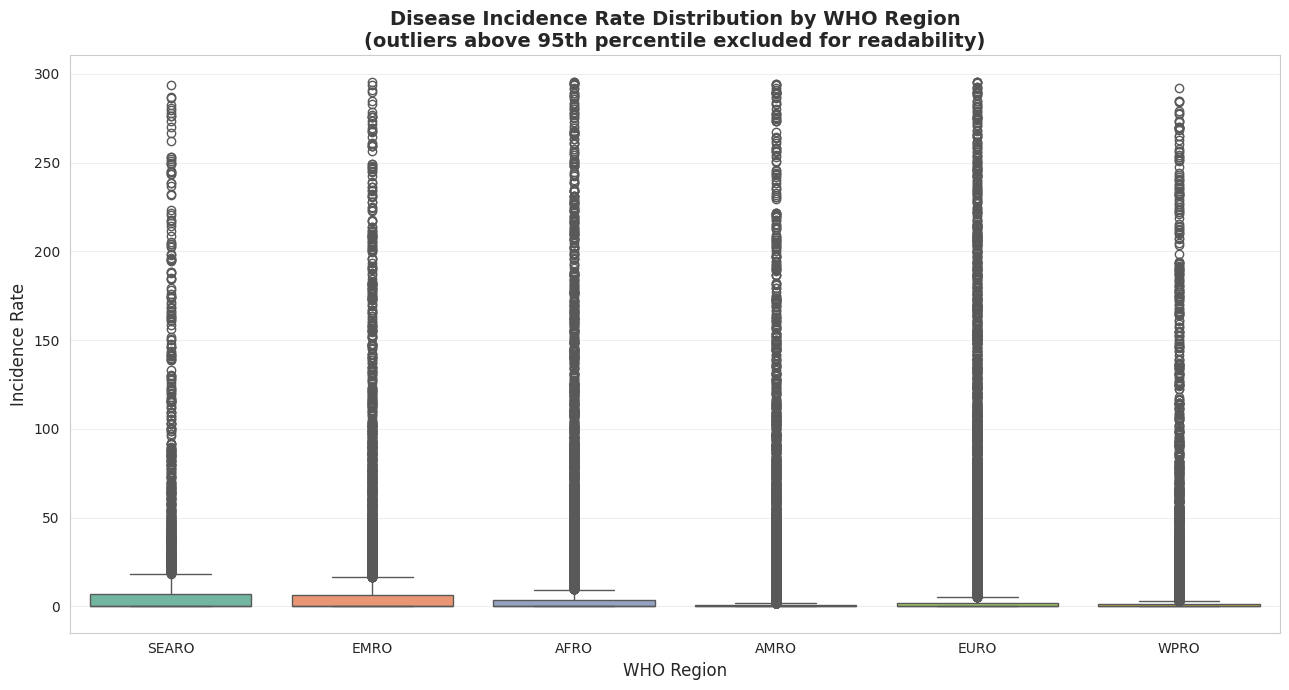

Incidence vs Coverage by region (full data, no cap):


,MEAN_INCIDENCE,MEDIAN_INCIDENCE,MAX_INCIDENCE,AVG_COVERAGE
WHO_REGION,,,,
AFRO,225.28,0.2,33833.7,69.94
WPRO,183.99,0.0,69101.3,80.44
SEARO,100.52,0.4,43863.6,78.07
EMRO,93.51,0.4,38473.7,78.55
EURO,50.37,0.0,41723.4,88.00
AMRO,41.49,0.0,35512.2,81.04


In [32]:
plt.figure(figsize=(13, 7))

box_df = master[master['WHO_REGION'] != 'UNKNOWN'].copy()

# Cap extreme outliers for visual readability
cap = box_df['INCIDENCE_RATE'].quantile(0.95)
box_plot_df = box_df[box_df['INCIDENCE_RATE'] <= cap]

order = (box_df.groupby('WHO_REGION')['INCIDENCE_RATE']
         .median().sort_values(ascending=False).index)

sns.boxplot(data=box_plot_df, x='WHO_REGION', y='INCIDENCE_RATE',
            order=order, palette='Set2')

plt.title('Disease Incidence Rate Distribution by WHO Region\n(outliers above 95th percentile excluded for readability)',
          fontsize=14, fontweight='bold')
plt.xlabel('WHO Region', fontsize=12)
plt.ylabel('Incidence Rate', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Full statistics (on uncapped data)
summary = (box_df.groupby('WHO_REGION')
           .agg(MEAN_INCIDENCE=('INCIDENCE_RATE','mean'),
                MEDIAN_INCIDENCE=('INCIDENCE_RATE','median'),
                MAX_INCIDENCE=('INCIDENCE_RATE','max'),
                AVG_COVERAGE=('AVG_COVERAGE','mean'))
           .sort_values('MEAN_INCIDENCE', ascending=False).round(2))

print("Incidence vs Coverage by region (full data, no cap):")
display(summary)

**Answer: AFRO carries the highest average disease burden, but WPRO is the key anomaly — high coverage combined with high incidence.**

| WHO Region | Mean Incidence | Median Incidence | Max Incidence | Avg Coverage |
|---|---|---|---|---|
| AFRO | **225.28** | 0.2 | 33,833.7 | 69.94% |
| WPRO | **183.99** | 0.0 | 69,101.3 | 80.44% |
| SEARO | 100.52 | 0.4 | 43,863.6 | 78.07% |
| EMRO | 93.51 | 0.4 | 38,473.7 | 78.55% |
| EURO | 50.37 | 0.0 | 41,723.4 | 88.00% |
| AMRO | 41.49 | 0.0 | 35,512.2 | 81.04% |

**Key findings:**

1. **The distribution is extremely zero-inflated — every region has a median at or near zero.** This is why the boxplot appears flat: in the large majority of country-year-disease combinations, zero cases are reported. Disease burden is not a steady background level; it is concentrated in rare, severe outbreak events, which appear as the dense outlier columns above each box.

2. **AFRO has the highest mean incidence (225.28) and the lowest coverage (69.9%)** — the two findings are consistent and reinforce the conclusion from Chart 7 that low coverage and high disease burden travel together.

3. **WPRO is the significant anomaly answering Easy Q10 directly.** Western Pacific has the second-highest mean incidence (183.99) despite above-average coverage of 80.4% — better than SEARO, EMRO and AFRO, all of which record lower incidence. It also records the single highest incidence value in the dataset (69,101.3). High vaccination coverage alone has not suppressed disease burden in this region.

4. **Possible explanations for the WPRO anomaly:** the region contains countries with dense urban populations where transmission is rapid once an outbreak starts; coverage averaged across a region can conceal severely under-vaccinated pockets within otherwise well-covered countries; and stronger surveillance systems in parts of WPRO may detect and report more cases that go uncounted elsewhere.

5. **Mean vastly exceeds median in every region** (AFRO: 225.28 vs 0.2), confirming that regional averages are driven by a small number of catastrophic outbreak years rather than by typical conditions. Outbreak prevention, not baseline reduction, is the operative goal.

6. **Maximum incidence is high in every region without exception** — even EURO, the best-covered region, records a peak of 41,723.4. No region is immune to severe outbreaks, reinforcing that high average coverage does not eliminate outbreak risk if immunity gaps persist.

**Recommendation:** AFRO requires coverage expansion as the primary intervention. WPRO requires a different approach — sub-national coverage analysis to locate immunity pockets, since region-level coverage figures are evidently masking vulnerable populations. For all regions, the zero-inflated distribution argues for investment in rapid outbreak-response capacity alongside routine immunization.

## Chart 11 — Measles Deep Dive: Coverage vs Cases Over Time

**Q (Scenario 2 / Scenario 6):** How effective has the measles vaccination campaign been, and is the world on track for 95% measles coverage by 2030?

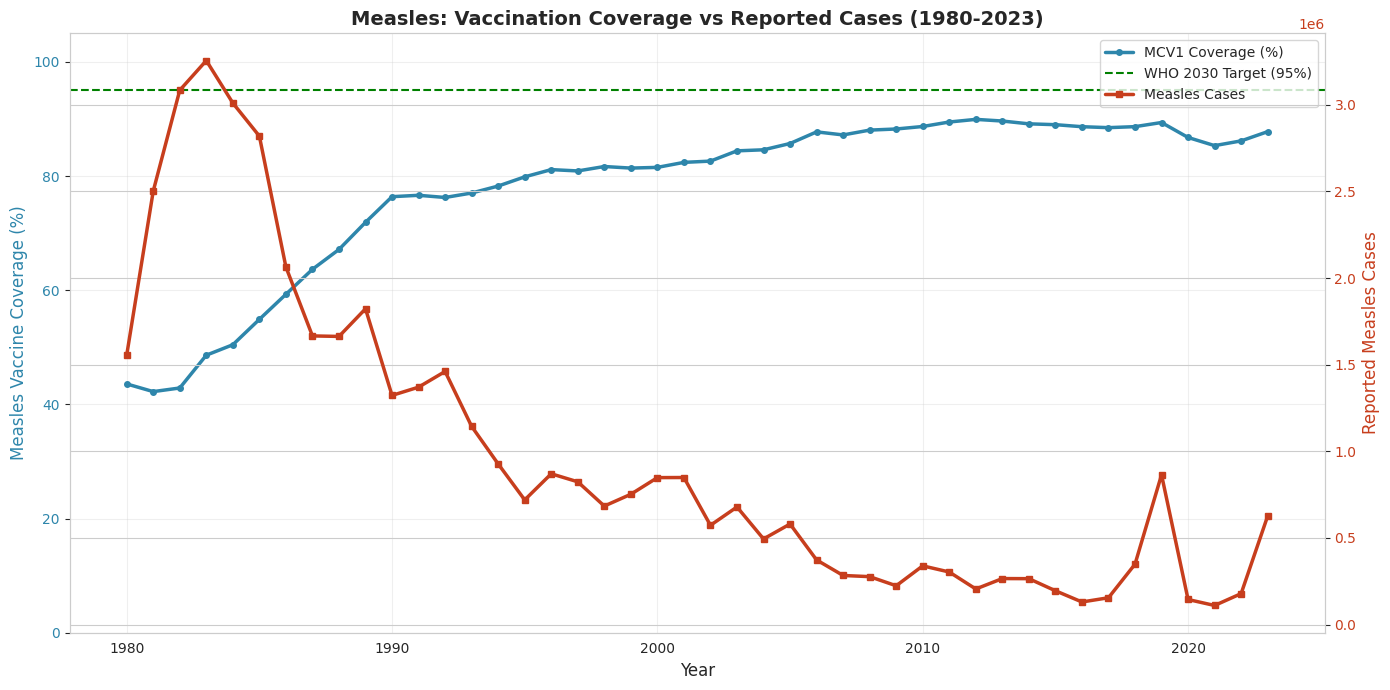

Correlation between MCV1 coverage and measles cases: r = -0.9262 (p = 2.10e-19)

1980: coverage  43.6%  |  cases    1,555,183
1990: coverage  76.4%  |  cases    1,322,881
2000: coverage  81.5%  |  cases      848,442
2010: coverage  88.7%  |  cases      339,217
2019: coverage  89.4%  |  cases      864,680
2020: coverage  86.8%  |  cases      145,034
2023: coverage  87.8%  |  cases      626,857

Peak MCV1 coverage: 89.9% in 2012
2023 coverage     : 87.8%  |  Gap to 95%: 7.2 pp


In [33]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# MCV1 coverage over time
mcv = (coverage[coverage['ANTIGEN'] == 'MCV1']
       .groupby('YEAR')['COVERAGE'].mean().reset_index())

# Measles cases over time
mcases = (master[master['DISEASE_DESCRIPTION'] == 'Measles']
          .groupby('YEAR')['CASES'].sum().reset_index())

ax1.plot(mcv['YEAR'], mcv['COVERAGE'], color='#2E86AB',
         marker='o', markersize=4, linewidth=2.5, label='MCV1 Coverage (%)')
ax1.axhline(95, color='green', linestyle='--', linewidth=1.5, label='WHO 2030 Target (95%)')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Measles Vaccine Coverage (%)', fontsize=12, color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1.set_ylim(0, 105)

ax2 = ax1.twinx()
ax2.plot(mcases['YEAR'], mcases['CASES'], color='#C73E1D',
         marker='s', markersize=4, linewidth=2.5, label='Measles Cases')
ax2.set_ylabel('Reported Measles Cases', fontsize=12, color='#C73E1D')
ax2.tick_params(axis='y', labelcolor='#C73E1D')

plt.title('Measles: Vaccination Coverage vs Reported Cases (1980-2023)',
          fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

m = pd.merge(mcv, mcases, on='YEAR')
r, p = stats.pearsonr(m['COVERAGE'], m['CASES'])
print(f"Correlation between MCV1 coverage and measles cases: r = {r:.4f} (p = {p:.2e})\n")

for yr in [1980, 1990, 2000, 2010, 2019, 2020, 2023]:
    row = m[m['YEAR'] == yr]
    if not row.empty:
        print(f"{yr}: coverage {row['COVERAGE'].values[0]:5.1f}%  |  cases {row['CASES'].values[0]:>12,.0f}")

peak = m.loc[m['COVERAGE'].idxmax()]
print(f"\nPeak MCV1 coverage: {peak['COVERAGE']:.1f}% in {int(peak['YEAR'])}")
print(f"2023 coverage     : {m.iloc[-1]['COVERAGE']:.1f}%  |  Gap to 95%: {95 - m.iloc[-1]['COVERAGE']:.1f} pp")

**Answer: The measles campaign has been highly effective — a near-perfect inverse relationship (r = -0.93) — but the world is 7.2 points short of the 2030 target and progress is reversing.**

Correlation between MCV1 coverage and measles cases: **r = -0.9262 (p = 2.10e-19)**

| Year | MCV1 Coverage | Measles Cases |
|---|---|---|
| 1980 | 43.6% | 1,555,183 |
| 1990 | 76.4% | 1,322,881 |
| 2000 | 81.5% | 848,442 |
| 2010 | 88.7% | 339,217 |
| 2019 | 89.4% | 864,680 |
| 2020 | 86.8% | 145,034 |
| 2023 | 87.8% | 626,857 |

Peak coverage: **89.9% in 2012** | 2023: **87.8%** | Gap to 95%: **7.2 pp**

**Key findings:**

1. **r = -0.9262 is exceptionally strong** — far above the -0.21 seen across all diseases pooled in Chart 7. When a single disease is isolated and matched to its own specific vaccine, the protective effect becomes unmistakable. Coverage explains approximately 86% of the variance in measles cases (r² = 0.86).

2. **Cases fell 80% between 1980 and 2010** (1.56M to 339K) as coverage nearly doubled from 43.6% to 88.7%. This is the clearest demonstration of vaccine effectiveness in the dataset.

3. **Coverage peaked in 2012 and has declined since.** The world reached 89.9% and then went backwards to 87.8% — meaning the 95% target is now further away than it was a decade ago. Reaching it by 2030 requires reversing a twelve-year trend, not merely continuing current efforts.

4. **The 2019 spike (864,680 cases) preceded the pandemic** and coincided with coverage slipping below 90%. This shows measles rebounds quickly once coverage falls even slightly, because measles requires ~95% coverage for herd immunity — a higher threshold than almost any other disease.

5. **The 2020 figure (145,034) is a reporting artifact, not a success.** Cases appear to collapse in 2020 while coverage also fell — a biologically impossible combination. Pandemic lockdowns suppressed both surveillance and healthcare-seeking behaviour. The 2023 rebound to 626,857 reveals the true underlying trend.

6. **2023 cases are 85% above the 2016 low point.** Measles is actively resurging.

**Conclusion for Scenario 6:** the world is not on track for 95% measles coverage by 2030. Closing a 7.2-point gap requires accelerating from a currently negative trajectory, and the 2023 case rebound indicates the consequences of inaction are already materialising.

## Chart 12 — Vaccine Introduction Timelines Across WHO Regions

**Q (Medium 6 / Medium 1):** Are there significant disparities in vaccine introduction timelines across WHO regions?

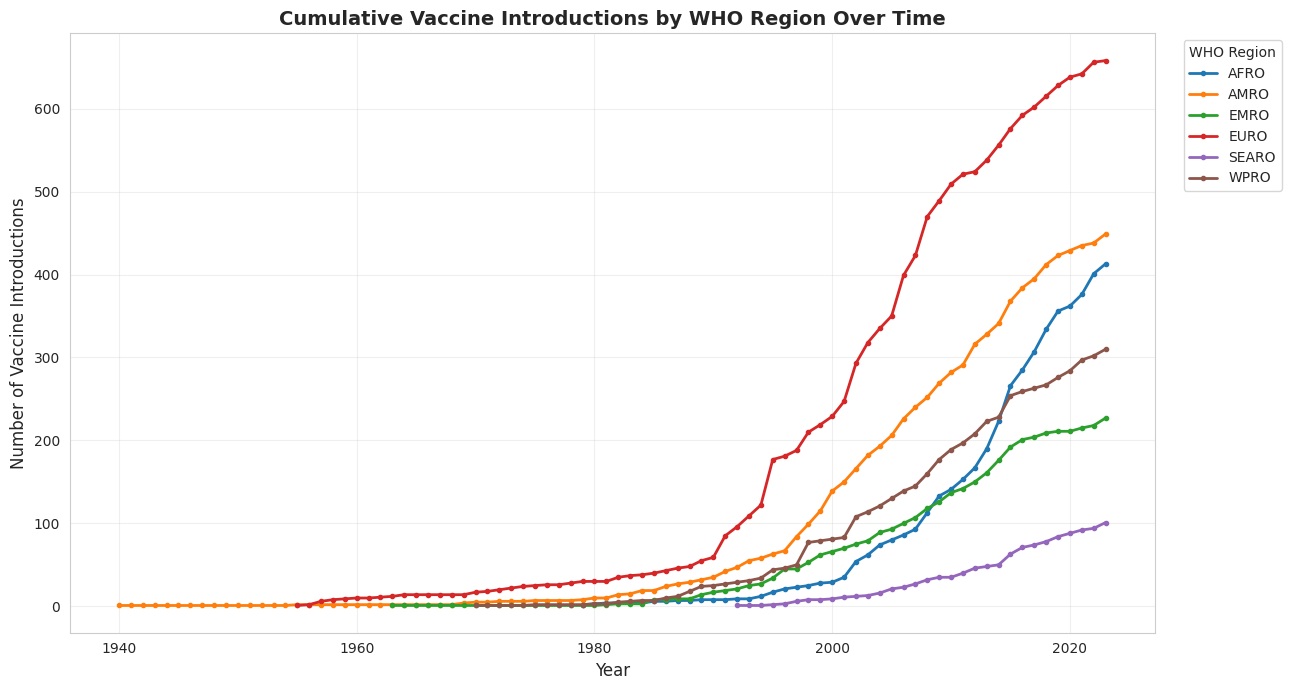

Vaccine introduction status by region (2023):


INTRO,High risk area,ND,No,Yes,Yes (A),Yes (O),Yes (P),Yes (R)
WHO_REGION,,,,,,,,
AFRO,0.10,0.00,57.45,41.84,0.00,0.00,0.41,0.20
AMRO,0.27,0.00,34.01,61.09,0.00,0.27,0.68,3.67
EMRO,0.00,0.23,44.67,51.47,0.00,0.00,0.23,3.40
EURO,0.00,0.00,34.68,59.12,0.09,0.00,0.63,5.48
SEARO,0.00,0.00,54.55,43.72,0.00,0.00,0.87,0.87
WPRO,0.00,0.00,43.21,54.67,0.00,0.00,0.35,1.76


In [34]:
## Chart 12 — Vaccine Introduction Impact
plt.figure(figsize=(13, 7))

intro_yes = intro[intro['INTRO'] == 'Yes']
intro_trend = (intro_yes.groupby(['YEAR', 'WHO_REGION'])
               .size().reset_index(name='VACCINES_INTRODUCED'))

for region in sorted(intro_trend['WHO_REGION'].dropna().unique()):
    d = intro_trend[intro_trend['WHO_REGION'] == region]
    plt.plot(d['YEAR'], d['VACCINES_INTRODUCED'], marker='o',
             markersize=3, linewidth=2, label=region)

plt.title('Cumulative Vaccine Introductions by WHO Region Over Time',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Vaccine Introductions', fontsize=12)
plt.legend(title='WHO Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Vaccine introduction status by region (2023):")
latest = intro[intro['YEAR'] == 2023]
pivot = pd.crosstab(latest['WHO_REGION'], latest['INTRO'], normalize='index') * 100
display(pivot.round(2))

**Answer: Yes — substantial disparities exist in both timing and current completeness of vaccine introduction.**

Vaccine introduction status by region (2023, % of records):

| Region | Introduced (Yes) | Not introduced (No) |
|---|---|---|
| AMRO | **61.09%** | 34.01% |
| EURO | **59.12%** | 34.68% |
| WPRO | 54.67% | 43.21% |
| EMRO | 51.47% | 44.67% |
| SEARO | 43.72% | 54.55% |
| AFRO | **41.84%** | **57.45%** |

**Key findings:**

1. **AFRO has the lowest introduction rate (41.84%) and the highest non-introduction rate (57.45%)** — the majority of available vaccines have still not been introduced into African national programmes. This compounds the coverage deficit found in Chart 2: AFRO delivers fewer vaccine types *and* achieves lower coverage on those it does deliver.

2. **A 19.25 percentage point gap separates AMRO (61.09%) from AFRO (41.84%)** in vaccine portfolio completeness.

3. **EURO led adoption throughout and remains furthest ahead in absolute terms** (~650 cumulative introductions versus SEARO's ~100). EURO's curve rises from the 1960s onward, while AFRO and SEARO remain nearly flat until the late 1990s — a delay of roughly three decades in beginning meaningful vaccine adoption.

4. **AFRO's adoption accelerated sharply after 2010**, with its curve steepening to overtake EMRO and approach WPRO. This coincides with the expansion of Gavi-supported programmes, showing that targeted international funding can compress adoption timelines.

5. **SEARO is the outlier at the bottom (~100 introductions)**, but this partly reflects region size — SEARO contains only 11 member states, so fewer country-vaccine combinations are possible. Its 43.72% introduction rate is a fairer comparison and still places it second-lowest.

6. **Introduction is a prerequisite for coverage.** A vaccine that has never been introduced cannot achieve any coverage at all, meaning AFRO's 57.45% non-introduction rate places a hard ceiling on the disease burden it can address, independent of delivery-system performance.

**Recommendation:** for AFRO and SEARO, vaccine introduction should be treated as a distinct policy priority separate from coverage improvement. Expanding coverage of existing vaccines cannot protect against diseases for which no vaccine has been introduced.

## Chart 13 — High-Priority Disease Coverage Gaps (TB and Hepatitis B)

**Q (Medium 9):** What are the gaps in coverage for vaccines targeting high-priority diseases such as TB and Hepatitis B?

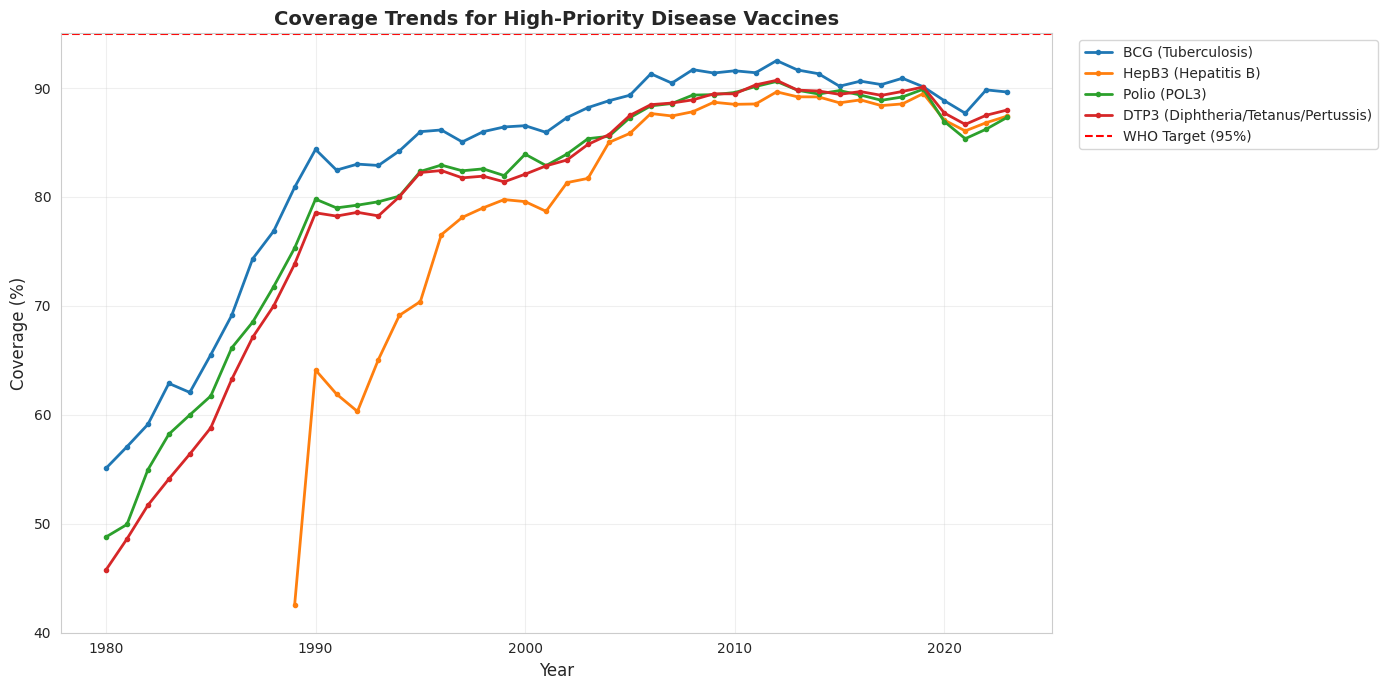

Current coverage and gap to 95% target (2023):

BCG (Tuberculosis)                        : 89.64%  |  gap  5.36 pp
HepB3 (Hepatitis B)                       : 87.43%  |  gap  7.57 pp
Polio (POL3)                              : 87.31%  |  gap  7.69 pp
DTP3 (Diphtheria/Tetanus/Pertussis)       : 87.98%  |  gap  7.02 pp

Regional coverage for priority vaccines (2023):


ANTIGEN,BCG,HEPB3
WHO_REGION,,
AFRO,87.69,85.42
AMRO,89.43,85.15
EMRO,88.60,87.53
EURO,93.15,89.47
SEARO,91.93,86.03
WPRO,87.99,89.15


In [35]:
plt.figure(figsize=(14, 7))

priority = {'BCG': 'BCG (Tuberculosis)',
            'HEPB3': 'HepB3 (Hepatitis B)',
            'POL3': 'Polio (POL3)',
            'DTPCV3': 'DTP3 (Diphtheria/Tetanus/Pertussis)'}

pr = (coverage[coverage['ANTIGEN'].isin(priority.keys())]
      .groupby(['YEAR', 'ANTIGEN'])['COVERAGE'].mean().reset_index())

for code, label in priority.items():
    d = pr[pr['ANTIGEN'] == code]
    plt.plot(d['YEAR'], d['COVERAGE'], marker='o', markersize=3,
             linewidth=2, label=label)

plt.axhline(95, color='red', linestyle='--', linewidth=1.5, label='WHO Target (95%)')
plt.title('Coverage Trends for High-Priority Disease Vaccines',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Coverage (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Current coverage and gap to 95% target (2023):\n")
for code, label in priority.items():
    d = pr[(pr['ANTIGEN'] == code) & (pr['YEAR'] == 2023)]
    if not d.empty:
        c = d['COVERAGE'].values[0]
        print(f"{label:42s}: {c:5.2f}%  |  gap {95-c:5.2f} pp")

print("\nRegional coverage for priority vaccines (2023):")
reg_pr = (coverage[(coverage['ANTIGEN'].isin(['BCG','HEPB3'])) &
                   (coverage['YEAR'] == 2023)]
          .merge(intro[['COUNTRY_CODE','WHO_REGION']].drop_duplicates('COUNTRY_CODE'),
                 on='COUNTRY_CODE', how='left'))
display(reg_pr.groupby(['WHO_REGION','ANTIGEN'])['COVERAGE'].mean().unstack().round(2))

**Answer: All four high-priority vaccines sit 5-8 percentage points below the 95% target, with Hepatitis B showing the widest gap and the most uneven regional distribution.**

Current coverage and gap to target (2023):

| Vaccine | Disease | Coverage | Gap to 95% |
|---|---|---|---|
| BCG | Tuberculosis | 89.64% | **5.36 pp** |
| POL3 | Polio | 87.31% | 7.69 pp |
| DTP3 | Diphtheria/Tetanus/Pertussis | 87.98% | 7.02 pp |
| HEPB3 | Hepatitis B | 87.43% | **7.57 pp** |

Regional coverage for BCG and HepB3 (2023):

| Region | BCG | HepB3 | Difference |
|---|---|---|---|
| AFRO | 87.69% | **85.42%** | -2.27 |
| AMRO | 89.43% | **85.15%** | -4.28 |
| EMRO | 88.60% | 87.53% | -1.07 |
| EURO | **91.15%** | 89.47% | -1.68 |
| SEARO | **91.93%** | **86.03%** | **-5.90** |
| WPRO | 87.99% | 89.15% | +1.16 |

**Key findings:**

1. **No high-priority vaccine reaches the 95% target anywhere.** The best single figure in the entire table is SEARO's BCG at 91.93% — still over three points short. These are the vaccines protecting against the most severe diseases, making the universal shortfall a critical finding.

2. **BCG consistently outperforms the other three** (89.64% globally, highest in every region except WPRO). BCG is administered as a single dose at birth, when mothers are already in contact with health facilities. POL3, DTP3 and HEPB3 all require a child to return for multiple visits — confirming the dose drop-off mechanism identified in Chart 8.

3. **Hepatitis B entered the programme roughly a decade late.** The HepB3 line begins around 1989 at 42%, while BCG and DTP3 were already above 55% in 1980. Despite this late start, HepB3 has converged to within 2.2 points of BCG, demonstrating that a delayed vaccine can catch up once integrated into an existing delivery system.

4. **SEARO shows the largest internal inconsistency: 91.93% BCG but only 86.03% HepB3, a 5.90-point gap.** The region delivers the birth-dose vaccine extremely well but loses nearly 6 percentage points on the three-dose series — a retention failure rather than an access failure, and therefore a relatively inexpensive one to correct.

5. **AMRO shows a similar pattern** (89.43% BCG vs 85.15% HepB3, -4.28 points), and records the lowest HepB3 coverage of any region.

6. **All four vaccines peaked around 2010-2015 and have declined since**, with a pronounced drop after 2019. The high-priority vaccines were not protected from the pandemic disruption affecting the wider programme.

**Recommendation:** the BCG-versus-HepB3 gap identifies where the loss occurs. Since BCG proves that health systems successfully reach around 90% of newborns, the shortfall in HepB3, DTP3 and POL3 is concentrated in follow-up visits. Defaulter tracking in SEARO and AMRO offers the highest return, as both already achieve strong first-contact coverage.

## Chart 14 — Correlation Heatmap

**Q (Easy 1 / overall):** Which variables in the dataset are related to each other, and how strongly?

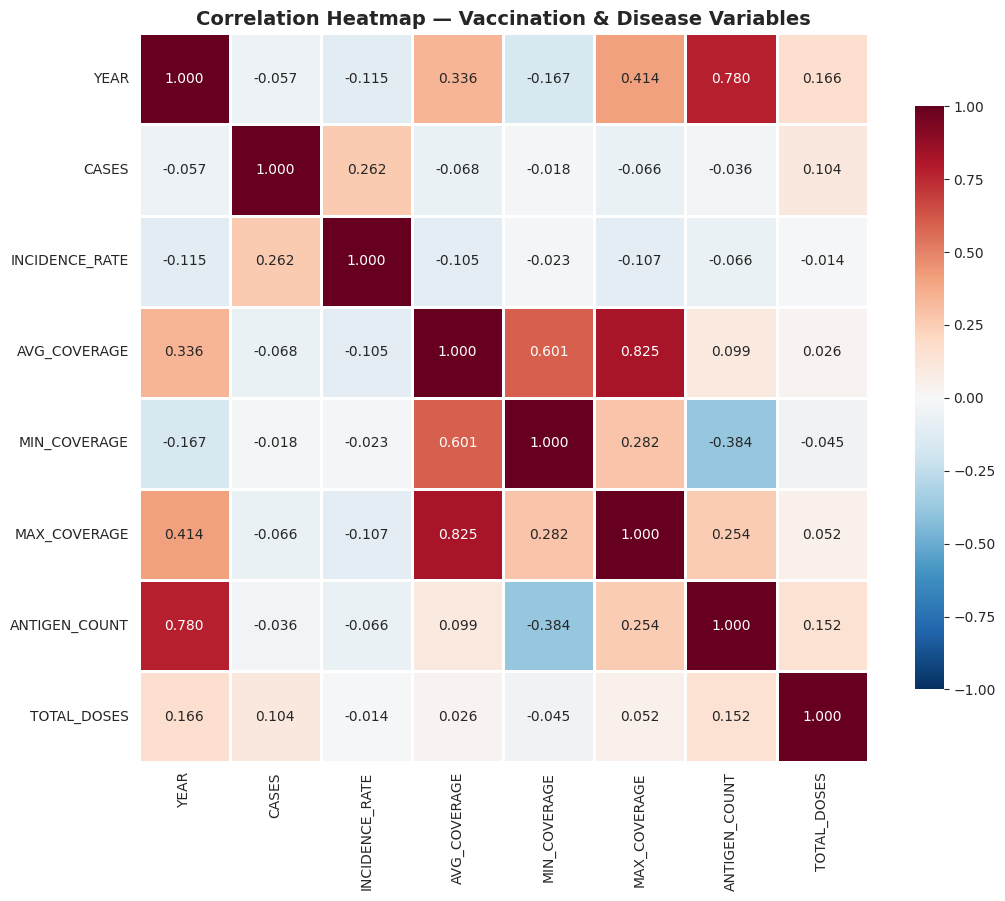

Correlations with INCIDENCE_RATE (sorted):


,INCIDENCE_RATE
YEAR,-0.1149
MAX_COVERAGE,-0.1072
AVG_COVERAGE,-0.1052
ANTIGEN_COUNT,-0.0660
MIN_COVERAGE,-0.0229
TOTAL_DOSES,-0.0135
CASES,0.2623


In [36]:
plt.figure(figsize=(11, 9))

num_cols = ['YEAR', 'CASES', 'INCIDENCE_RATE', 'AVG_COVERAGE',
            'MIN_COVERAGE', 'MAX_COVERAGE', 'ANTIGEN_COUNT', 'TOTAL_DOSES']

corr = master[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap — Vaccination & Disease Variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with INCIDENCE_RATE (sorted):")
display(corr['INCIDENCE_RATE'].drop('INCIDENCE_RATE').sort_values().to_frame().round(4))

**Answer: Every coverage measure correlates negatively with disease incidence, confirming the protective effect; the strongest relationships in the matrix are structural.**

Correlations with INCIDENCE_RATE:

| Variable | Correlation |
|---|---|
| CASES | **+0.2623** |
| YEAR | -0.1149 |
| MAX_COVERAGE | **-0.1072** |
| AVG_COVERAGE | **-0.1052** |
| ANTIGEN_COUNT | -0.0660 |
| MIN_COVERAGE | -0.0229 |
| TOTAL_DOSES | -0.0135 |

**Key findings:**

1. **All five vaccination-related variables correlate negatively with incidence, without exception.** No coverage metric shows a positive association with disease. The consistency across independently measured variables is itself evidence: a spurious relationship would not hold uniformly across average, minimum, maximum coverage, antigen count and total doses.

2. **YEAR vs ANTIGEN_COUNT is the strongest relationship in the matrix (+0.780).** The number of distinct vaccines offered per country has risen steadily over time — immunization programmes have broadened, not merely deepened.

3. **AVG_COVERAGE vs MAX_COVERAGE (+0.825) and AVG vs MIN_COVERAGE (+0.601)** are structural correlations, since all three are computed from the same underlying coverage figures. The asymmetry is informative: average tracks maximum far more closely than minimum, meaning a country's weakest-performing vaccine is often a distant outlier from its overall profile.

4. **CASES vs INCIDENCE_RATE is only +0.2623**, which is lower than expected given both measure disease burden. Incidence is normalised by population while raw cases are not, so a large country with moderate incidence can record more cases than a small country with severe incidence. This validates the use of incidence rate as the fairer cross-country comparison metric.

5. **ANTIGEN_COUNT vs MIN_COVERAGE is negative (-0.384).** Countries offering more vaccine types tend to have a lower worst-performing vaccine. Expanding the portfolio introduces newly launched vaccines that have not yet scaled, pulling the minimum down — an expected consequence of programme expansion rather than a deterioration.

6. **Correlations here (-0.105) are weaker than the -0.9262 found for measles alone in Chart 11.** This matrix pools 13 diseases against overall coverage, mixing unrelated vaccine-disease pairs. Disease-specific analysis reveals the true effect size; pooled correlation dilutes it.

7. **YEAR vs INCIDENCE_RATE is negative (-0.1149)**, confirming that disease incidence has declined over the 44-year period alongside rising coverage.

## Chart 15 — Pair Plot

**Q (overall):** What are the multivariate relationships and distributions among the key numeric variables?

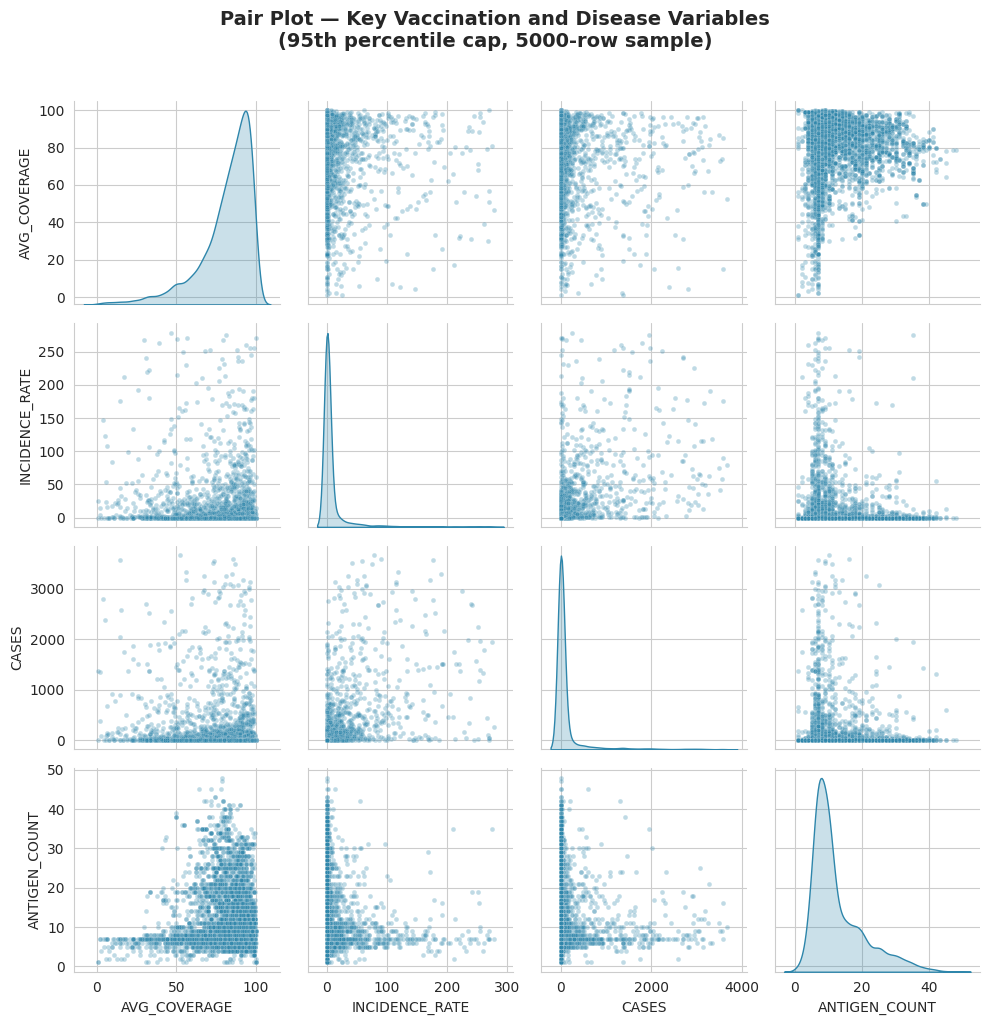

Summary statistics for pair plot variables:


,AVG_COVERAGE,INCIDENCE_RATE,CASES,ANTIGEN_COUNT
count,5000.00,5000.00,5000.00,5000.00
mean,81.21,8.80,117.20,12.56
std,16.61,29.78,405.73,7.76
min,1.00,0.00,0.00,1.00
25%,74.78,0.00,0.00,7.00
50%,85.93,0.00,0.00,10.00
75%,93.19,1.80,23.00,16.00
max,100.00,278.50,3667.00,48.00


In [37]:
pair_cols = ['AVG_COVERAGE', 'INCIDENCE_RATE', 'CASES', 'ANTIGEN_COUNT']

# Sample and cap outliers so the plot is readable
pp = master[pair_cols].copy()
pp = pp[(pp['INCIDENCE_RATE'] <= pp['INCIDENCE_RATE'].quantile(0.95)) &
        (pp['CASES'] <= pp['CASES'].quantile(0.95))]
pp = pp.sample(n=min(5000, len(pp)), random_state=42)

g = sns.pairplot(pp, diag_kind='kde',
                 plot_kws={'alpha': 0.3, 's': 12, 'color': '#2E86AB'},
                 diag_kws={'color': '#2E86AB', 'fill': True})

g.figure.suptitle('Pair Plot — Key Vaccination and Disease Variables\n(95th percentile cap, 5000-row sample)',
                  y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Summary statistics for pair plot variables:")
display(pp.describe().round(2))

**Answer: The pair plot confirms strong left-skew in coverage, extreme zero-inflation in both disease measures, and a visible triangular boundary between coverage and incidence.**

Summary statistics (5,000-row sample, 95th percentile cap):

| | AVG_COVERAGE | INCIDENCE_RATE | CASES | ANTIGEN_COUNT |
|---|---|---|---|---|
| mean | 81.21 | 8.80 | 117.20 | 12.56 |
| std | 16.61 | 29.78 | 405.73 | 7.76 |
| min | 1.00 | 0.00 | 0.00 | 1.00 |
| 25% | 74.78 | 0.00 | 0.00 | 7.00 |
| 50% | 85.93 | **0.00** | **0.00** | 10.00 |
| 75% | 93.19 | 1.80 | 23.00 | 16.00 |
| max | 100.00 | 278.50 | 3667.00 | 48.00 |

**Key findings:**

1. **Both INCIDENCE_RATE and CASES have a median of exactly 0.00, and their 25th percentiles are also 0.** More than half of all country-year-disease combinations report no cases at all. The KDE curves for both variables are near-vertical spikes at zero. Disease burden is episodic, not continuous.

2. **AVG_COVERAGE is strongly left-skewed** — median 85.93 exceeds mean 81.21, with a long tail of poorly covered country-years extending down to 1%. The density peaks sharply near 90%, showing most country-years cluster at high coverage while a minority perform catastrophically.

3. **The coverage-versus-incidence scatter shows a triangular envelope.** At low coverage, incidence values range from zero to very high; at high coverage, points compress toward zero. High coverage effectively caps the maximum possible incidence rather than guaranteeing zero cases — precisely the behaviour expected of herd immunity, and the reason the linear correlation is only moderate while the protective effect is real.

4. **ANTIGEN_COUNT is right-skewed** (mean 12.56, median 10.00, max 48), and its scatter against AVG_COVERAGE shows a dense mass at high coverage across all portfolio sizes. Offering more vaccine types does not by itself raise coverage — breadth and depth of a programme are independent dimensions.

5. **Standard deviation exceeds the mean for both CASES (405.73 vs 117.20) and INCIDENCE_RATE (29.78 vs 8.80)**, even after capping at the 95th percentile. This extreme dispersion is the statistical signature of outbreak-driven data and justifies using medians rather than means when summarising disease burden.

6. **No pair shows a clean linear relationship.** All scatters are L-shaped or triangular, indicating threshold effects rather than proportional ones — supporting the conclusion that vaccination works by crossing herd-immunity thresholds rather than delivering incremental protection.

# **Solution to Business Objective**

**1. Public Health Strategy — does vaccination work?**

Yes, and the evidence is strong. Mean disease incidence falls monotonically at every step up in coverage, from 499.5 at below 50% coverage to 68.2 at 90-100% — an 86.4% reduction. For measles specifically, where a single vaccine can be matched to a single disease, coverage and cases correlate at r = -0.9262, meaning coverage explains approximately 86% of the variance in case numbers. Measles, pertussis and tetanus have each fallen roughly 87% since the 1980s.

**2. Resource Allocation — where should investment go?**

- **By region:** AFRO, at 69.9% average coverage, is 25.1 points below target and 18.1 points behind the leading region.
- **By country:** the bottom 15 all fall below 60%, led by Somalia (42.1%), Nigeria (44.8%) and Chad (47.4%). Twelve are in Sub-Saharan Africa and several are conflict-affected, indicating that delivery-system capacity rather than vaccine supply is the binding constraint.
- **By efficiency:** the steepest incidence reductions occur when moving countries out of the below-70% band. Investment there yields far greater disease reduction per percentage point than improving already-high performers.
- **By absolute impact:** Nigeria is the single highest-value target, since its low coverage combined with a large population produces the greatest number of unvaccinated children.

**3. Disease Prevention — where is vaccination not working?**

WPRO is the clearest anomaly: the second-highest mean incidence (183.99) despite above-average coverage of 80.4%, and the highest single incidence value recorded in the dataset. Regional averages there are evidently masking under-vaccinated pockets, requiring sub-national analysis rather than further region-level investment.

Separately, dose drop-off represents a distinct and correctable failure. Roughly one in ten children who receive DTP dose 1 never receive dose 3 (9.37 percentage points lost), and the same pattern appears for pneumococcal vaccine (7.76 points). These children are already reached by the health system once, making retention a cheaper problem to solve than first-contact access.

**4. Global Health Policy — is the 95% target achievable?**

Not on the current trajectory. Only 3 of 214 countries have achieved 95% average coverage. Measles coverage peaked at 89.9% in 2012 and has since fallen to 87.8%, leaving a 7.2-point gap that is widening rather than closing. Measles cases in 2023 (626,857) are 85% above the 2016 low point.

# **Conclusion**

Four decades of global immunization effort have produced substantial and measurable results. Average coverage rose from 49.31% in 1980 to a peak near 89% in the mid-2010s, disease burden for the longest-tracked diseases fell by approximately 87%, and the equity gap between the best and worst performing WHO regions narrowed from 53.1 percentage points to 5.8 — an 89% reduction.

However, three findings qualify that success.

First, the 95% target has never been reached by any region in 44 years, and only 3 of 214 countries have achieved it. The shortfall is near-universal rather than confined to a few lagging states.

Second, progress has reversed since 2019. Coverage fell from its peak to 80.34% by 2023, and the decline affected all six WHO regions simultaneously. Measles cases rebounded accordingly, demonstrating that suppressed diseases return within two to three years of coverage slipping. Gains built over three decades proved fragile.

Third, coverage alone is insufficient. The triangular relationship between coverage and incidence shows that high coverage caps maximum outbreak severity rather than guaranteeing zero cases. WPRO's combination of high coverage and high incidence confirms that national averages can conceal dangerous immunity gaps.

**Priority recommendations:**

1. Restore pre-2019 coverage levels before expanding into new programmes, as the data shows disease resurgence follows coverage decline rapidly.
2. Fund catch-up campaigns for the cohort of children missed since 2019.
3. Invest in defaulter tracking to close the DTP1-DTP3 gap, recovering close to 10% of the target population at relatively low cost.
4. Target Nigeria and Ethiopia for maximum absolute impact, and Somalia, Chad and the Central African Republic for maximum rate improvement.
5. Conduct sub-national coverage analysis in WPRO to locate the immunity pockets that regional averages are hiding.
6. Treat vaccine introduction as a distinct priority from coverage in AFRO, where 57.45% of available vaccines remain unintroduced and no amount of delivery improvement can compensate.